In [14]:
import os
import io
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from adjustText import adjust_text

# Global matplotlib baseline styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'figure.dpi': 300
})

In [15]:

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.labelweight'] = 'bold'

In [48]:
def categorize_model(row):
    modality = str(row['Modality'])
    task = str(row['Task']).lower()
    model_name = str(row['Model']).lower()

    is_arctic = 'arctic-tilt' in model_name

    # 1. Route NuExtract
    if 'nuextract' in model_name:
        return 'NuExtract'

    # 2. Route Visual Models
    elif modality == 'Vision' and not is_arctic:
        return 'Visual Models'

    # 3. Route Text-Only Models (and Arctic-Tilt) with OCR tracking
    elif modality == 'Text-Only' or is_arctic:
        prefix = 'Arctic-Tilt' if is_arctic else 'Text-only'
        if task == 'docling':
            return f'{prefix} + Docling'
        elif task == 'deepseek':
            return f'{prefix} + DeepSeek OCR'
        else:
            return f'{prefix} + Tesseract' # Default fallback
    else:
        return 'Other'

category_styles = {
    # TEXT-ONLY (Green: #81b29a)
    'Text-only + Tesseract': {'color': '#81b29a', 'marker': 'o'},   # Circle
    'Text-only + Docling': {'color': '#81b29a', 'marker': 'D'},     # Diamond
    'Text-only + DeepSeek OCR': {'color': '#81b29a', 'marker': 's'},# Square

    # VISUAL (Orange: #f4a261)
    'Visual Models': {'color': '#f4a261', 'marker': '^'},           # Triangle (No OCR)

    # SPECIALIZED (Purple: #9b5de5)
    'Arctic-Tilt + Tesseract': {'color': '#9b5de5', 'marker': 'o'}, # Circle
    'Arctic-Tilt + Docling': {'color': '#9b5de5', 'marker': 'D'},   # Diamond
    'Arctic-Tilt + DeepSeek OCR': {'color': '#9b5de5', 'marker': 's'},# Square
    'NuExtract': {'color': '#9b5de5', 'marker': '^'}, # Triangle (No OCR)
}

In [49]:
# 1. OCR Energy Extraction
def get_ocr_energy_per_doc(dataset_name="VRDU", task_name="tesseract"):
    """Calculates the OCR energy per document from the respective OCR reports."""
    # Base path updated to your new structure
    base_path = '../benchmark/ocr_profiling/report/'

    try:
        if dataset_name == "VRDU":
            if task_name == "tesseract":
                df_ocr = pd.read_csv(f'{base_path}tesseract_vrdu.csv')
                wh_total = float(df_ocr['Total Energy Consumed (kWh)'].iloc[0]) * 1000
            elif task_name == "docling":
                df_ocr = pd.read_csv(f'{base_path}docling_vrdu.csv')
                wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            elif task_name == "deepseek":
                df_ocr = pd.read_csv(f'{base_path}deepseek_vrdu_report_bs10.csv')
                wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            else:
                return 0.0
            return wh_total / 500  # VRDU document count normalization

        elif dataset_name == "Kleister NDA":
            if task_name == "tesseract":
                df_ocr = pd.read_csv(f'{base_path}tesseract_kleister.csv')
            elif task_name == "docling":
                df_ocr = pd.read_csv(f'{base_path}docling_kleister.csv')
            elif task_name == "deepseek":
                df_ocr = pd.read_csv(f'{base_path}deepseek_kleister_bs5.csv')
            else:
                return 0.0

            wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            return wh_total / 337  # Kleister document count normalization

    except Exception as e:
        print(f"Error loading OCR data for {dataset_name} - {task_name}: {e}")
        return 0.0

# 2. Base Preprocessing Functions
def load_cleaned_energy_report(filepath):
    """Reads the CSV, adds a batch_size column, and aligns all rows."""
    if not os.path.exists(filepath): return pd.DataFrame()
    with open(filepath, 'r') as file: lines = file.readlines()
    if not lines: return pd.DataFrame()
    header = lines[0].strip('\n').split(',')
    if header[1] != 'batch_size': header.insert(1, 'batch_size')
    cleaned_lines = [','.join(header) + '\n']
    for line in lines[1:]:
        parts = line.strip('\n').split(',')
        if len(parts) == 39: parts.insert(1, '1')
        elif len(parts) > 40: parts = parts[:40]
        cleaned_lines.append(','.join(parts) + '\n')
    return pd.read_csv(io.StringIO(''.join(cleaned_lines)))

def parse_standard_report(file_path):
    """Parses a single standard run report CSV and returns extracted metrics."""
    df_temp = pd.read_csv(file_path)
    model_name = df_temp['model_name'].iloc[0] if 'model_name' in df_temp.columns else "unknown"
    batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1
    backend = df_temp['backend'].iloc[0] if 'backend' in df_temp.columns else "default"
    energy = df_temp['total_energy_wh'].iloc[0] if 'total_energy_wh' in df_temp.columns else 0.0

    # Exact Match Evaluation
    if 'avg_calculated_field_em' in df_temp.columns:
        exact_match = df_temp['avg_calculated_field_em'].iloc[0] * 100
    else:
        exact_match = df_temp['avg_field_em'].iloc[0] * 100 if 'avg_field_em' in df_temp.columns else 0.0

    # Fuzzy Match Evaluation
    fuzzy_match = df_temp['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_temp.columns else 0.0

    # F1 Score Evaluation
    if 'avg_calculated_document_f1' in df_temp.columns:
        f1_score = df_temp['avg_calculated_document_f1'].iloc[0] * 100
    else:
        f1_score = df_temp['avg_field_f1'].iloc[0] * 100 if 'avg_field_f1' in df_temp.columns else 0.0

    dataset = "VRDU" if "vrdu" in file_path else "Kleister NDA"
    modality = "Vision" if "vrdu_vision" in file_path or "kleister_nda_vl" in file_path else "Text-Only"

    if "deepseek" in file_path: task = "deepseek"
    elif "docling" in file_path: task = "docling"
    elif "tesseract" in file_path: task = "tesseract"
    elif modality == "Vision": task = "vision"
    else: task = "default"

    return {
        'Dataset': dataset, 'Model': model_name, 'Batch_Size': batch_size,
        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
        'Energy_Wh': energy, 'Modality': modality, 'Task': task, 'File_Path': file_path
    }

def load_all_data():
    """Unifies standard reports and standalone benchmarks into one DataFrame."""
    data_list = []
    standard_paths = [
        "../vrdu_noquant/run_report/*.csv",
        "../vrdu_quant/run_report/*.csv",
        "../vrdu_vision_noquant/run_report/*.csv",
        "../vrdu_vision_quant/run_report/*.csv",
        "../kleister_nda_noquant/run_report/*.csv",
        "../kleister_nda_quant/run_report/*.csv",
        "../kleister_nda_vl_noquant/run_report/*.csv",
        "../kleister_nda_vl_quant/run_report/*.csv",
    ]
    for path in standard_paths:
        for file in glob.glob(path):
            try: data_list.append(parse_standard_report(file))
            except: pass

    # 2. Parse Arctic Evaluation Logs & New Inference Energy Report
    arctic_dir = "../arctic_results/"
    inference_energy_path = "../arctic_results/inference_energy_report.csv"

    if os.path.exists(arctic_dir):
        try:
            # Use the custom loader instead of standard pd.read_csv
            energy_df = pd.DataFrame()
            if os.path.exists(inference_energy_path):
                energy_df = load_cleaned_energy_report(inference_energy_path)

            for file in glob.glob(os.path.join(arctic_dir, "evaluation_*.csv")):
                filename = os.path.basename(file)
                df_eval = pd.read_csv(file)

                # Dynamically find the correct Metric Key and Score columns
                metric_col = 'Metric / Entity Key' if 'Metric / Entity Key' in df_eval.columns else 'Entity Key / Metric'
                score_col = 'F1 Score' if 'F1 Score' in df_eval.columns else 'Fuzzy Match'

                # Exact Match Extraction
                em_row = df_eval[df_eval[metric_col].isin(['Average Field EM', 'avg_calculated_field_em']) |
                                 df_eval[metric_col].str.contains('Field EM|Exact Match|field_em', case=False, na=False)]
                em_row = em_row[~em_row[metric_col].str.contains('Subset', case=False, na=False)]
                exact_match = (em_row[score_col].dropna().iloc[0] * 100) if not em_row.empty else 0.0

                # Fuzzy & F1 Extraction
                fuzzy_row = df_eval[df_eval[metric_col].str.contains('Fuzzy|fuzzy_score', case=False, na=False)]
                fuzzy_match = (fuzzy_row[score_col].dropna().iloc[0] * 100) if not fuzzy_row.empty else 0.0

                f1_row = df_eval[df_eval[metric_col].str.contains('Document F1|Field F1|document_f1', case=False, na=False)]
                f1_score = (f1_row[score_col].dropna().iloc[0] * 100) if not f1_row.empty else 0.0

                # Determine standard parameters based on filename
                dataset = "VRDU" if "vrdu" in filename else "Kleister NDA"
                search_ds = "vrdu" if "vrdu" in filename else "kleister"

                if "docling" in filename:
                    task, search_task = "docling", "docling"
                elif "tesseract" in filename:
                    task, search_task = "tesseract", "tesseract"
                elif "deepseek" in filename:
                    task, search_task = "deepseek", "deepseek"
                elif "baseline" in filename:
                    task, search_task = "default", "default"
                else:
                    task = "default"
                    search_task = "registration" if "vrdu" in filename else "ready"

                # Energy Matching Logic
                energy_wh = 0.0
                if not energy_df.empty and 'dataset_name' in energy_df.columns:
                    mask = (
                        energy_df['dataset_name'].str.contains(search_ds, case=False, na=False) &
                        energy_df['dataset_name'].str.contains(search_task, case=False, na=False)
                    )
                    energy_match = energy_df[mask]
                    if not energy_match.empty:
                        energy_wh = energy_match['energy_consumed'].iloc[0] * 1000

                # Append for batch sizes 1 and 10 expected by the master pipeline
                for bs_config in [1, 10]:
                    data_list.append({
                        'Dataset': dataset, 'Model': 'Arctic-Tilt', 'Batch_Size': bs_config,
                        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                        'Energy_Wh': energy_wh, 'Modality': 'Text-Only', 'Task': task, 'File_Path': file
                    })
        except Exception as e:
            print(f"Error parsing arctic_results: {e}")

    # 3. Parse Standalone NuExtract Benchmark Results
    nuextract_configs = [
        {'path': '../benchmark/nuextract_vrdu/nuextract_vrdu_metrics.csv', 'dataset': 'VRDU'},
        {'path': '../benchmark/nuextract_kleister/kleister_standalone_metrics_output.csv', 'dataset': 'Kleister NDA'}
    ]
    for cfg in nuextract_configs:
        if os.path.exists(cfg['path']):
            try:
                df_nu = pd.read_csv(cfg['path'])

                # Fetch exact match, f1 score and fuzzy match
                exact_match = df_nu['avg_calculated_field_em'].iloc[0] * 100 if 'avg_calculated_field_em' in df_nu.columns else df_nu['avg_field_em'].iloc[0] * 100
                f1_score = df_nu['avg_calculated_document_f1'].iloc[0] * 100 if 'avg_calculated_document_f1' in df_nu.columns else df_nu.get('avg_field_f1', pd.Series([0.0])).iloc[0] * 100
                fuzzy_match = df_nu['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_nu.columns else 0.0

                energy = df_nu['total_energy_wh'].iloc[0]

                data_list.append({
                    'Model': 'NuExtract-2.0-4B', 'Dataset': cfg['dataset'], 'Modality': 'Vision',
                    'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                    'Energy_Wh': energy, 'Batch_Size': 1, 'Task': 'vision', 'File_Path': cfg['path']
                })
            except Exception as e:
                print(f"Error loading NuExtract path {cfg['path']}: {e}")

    df_all = pd.DataFrame(data_list)
    if not df_all.empty:
        df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)

    return df_all
def load_all_data():
    """Unifies standard reports and standalone benchmarks into one DataFrame."""
    data_list = []
    standard_paths = [
        "../vrdu_noquant/run_report/*.csv",
        "../vrdu_quant/run_report/*.csv",
        "../vrdu_vision_noquant/run_report/*.csv",
        "../vrdu_vision_quant/run_report/*.csv",
        "../kleister_nda_noquant/run_report/*.csv",     # Added Kleister Text paths
        "../kleister_nda_quant/run_report/*.csv",
        "../kleister_nda_vl_noquant/run_report/*.csv",  # Added Kleister Vision paths
        "../kleister_nda_vl_quant/run_report/*.csv",
    ]
    for path in standard_paths:
        for file in glob.glob(path):
            try: data_list.append(parse_standard_report(file))
            except: pass

 # 2. Parse Arctic Evaluation Logs & New Inference Energy Report
    arctic_dir = "../arctic_results/"
    inference_energy_path = "../arctic_results/inference_energy_report.csv"

    if os.path.exists(arctic_dir):
        try:
            # Use the custom loader instead of standard pd.read_csv
            energy_df = pd.DataFrame()
            if os.path.exists(inference_energy_path):
                energy_df = load_cleaned_energy_report(inference_energy_path)

            for file in glob.glob(os.path.join(arctic_dir, "evaluation_*.csv")):
                filename = os.path.basename(file)
                df_eval = pd.read_csv(file)

                # Dynamically find the correct Metric Key and Score columns
                metric_col = 'Metric / Entity Key' if 'Metric / Entity Key' in df_eval.columns else 'Entity Key / Metric'
                score_col = 'F1 Score' if 'F1 Score' in df_eval.columns else 'Fuzzy Match'

                # Exact Match Extraction
                em_row = df_eval[df_eval[metric_col].isin(['Average Field EM', 'avg_calculated_field_em']) |
                                 df_eval[metric_col].str.contains('Field EM|Exact Match|field_em', case=False, na=False)]
                em_row = em_row[~em_row[metric_col].str.contains('Subset', case=False, na=False)]
                exact_match = (em_row[score_col].dropna().iloc[0] * 100) if not em_row.empty else 0.0

                # Determine standard parameters based on filename
                dataset = "VRDU" if "vrdu" in filename else "Kleister NDA"
                search_ds = "vrdu" if "vrdu" in filename else "kleister"

                if "docling" in filename:
                    task, search_task = "docling", "docling"
                elif "tesseract" in filename:
                    task, search_task = "tesseract", "tesseract"
                elif "deepseek" in filename:
                    task, search_task = "deepseek", "deepseek"
                elif "baseline" in filename:
                    task, search_task = "default", "default"
                else:
                    task = "default"
                    search_task = "registration" if "vrdu" in filename else "ready"

                # Energy Matching Logic
                energy_wh = 0.0
                if not energy_df.empty and 'dataset_name' in energy_df.columns:
                    mask = (
                        energy_df['dataset_name'].str.contains(search_ds, case=False, na=False) &
                        energy_df['dataset_name'].str.contains(search_task, case=False, na=False)
                    )
                    energy_match = energy_df[mask]
                    if not energy_match.empty:
                        energy_wh = energy_match['energy_consumed'].iloc[0] * 1000

                # Append for batch sizes 1 and 10 expected by the master pipeline
                for bs_config in [1, 10]:
                    data_list.append({
                        'Dataset': dataset, 'Model': 'Arctic-Tilt', 'Batch_Size': bs_config,
                        'Exact_Match': exact_match, 'Energy_Wh': energy_wh,
                        'Modality': 'Text-Only', 'Task': task, 'File_Path': file
                    })
        except Exception as e:
            print(f"Error parsing arctic_results: {e}")

    # 3. Parse Standalone NuExtract Benchmark Results
    nuextract_configs = [
        {'path': '../benchmark/nuextract_vrdu/nuextract_vrdu_metrics.csv', 'dataset': 'VRDU'},
        {'path': '../benchmark/nuextract_kleister/kleister_standalone_metrics_output.csv', 'dataset': 'Kleister NDA'}
    ]
    for cfg in nuextract_configs:
        if os.path.exists(cfg['path']):
            try:
                df_nu = pd.read_csv(cfg['path'])
                exact_match = df_nu['avg_calculated_field_em'].iloc[0] * 100 if 'avg_calculated_field_em' in df_nu.columns else df_nu['avg_field_em'].iloc[0] * 100
                energy = df_nu['total_energy_wh'].iloc[0]

                data_list.append({
                    'Model': 'NuExtract-2.0-4B', 'Dataset': cfg['dataset'], 'Modality': 'Vision',
                    'Exact_Match': exact_match, 'Energy_Wh': energy,
                    'Batch_Size': 1, 'Task': 'vision', 'File_Path': cfg['path']
                })
            except Exception as e:
                print(f"Error loading NuExtract path {cfg['path']}: {e}")
    df_all = pd.DataFrame(data_list)
    if not df_all.empty:
        df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)
    return df_all

df_all = load_all_data()

In [50]:
# 1. Constants
TARGET_DATASET = 'VRDU'
TEST_SET_SIZES = {'VRDU': 500, 'Kleister NDA': 337}

# 2. Filter for Target Dataset & Unquantized Models Only
df_plot = df_all[df_all['Dataset'] == TARGET_DATASET].copy()

# THE FIX: Keep explicit 'noquant', drop explicit 'quant', keep standalone paths (Arctic/NuExtract)
def is_unquantized(path):
    path_str = str(path).lower()
    if 'noquant' in path_str: return True
    if 'quant' in path_str and 'noquant' not in path_str: return False
    return True # Keep standalone benchmarks safely

unquant_mask = df_plot['File_Path'].apply(is_unquantized)
df_plot = df_plot[unquant_mask].copy()

# 3. Calculate End-to-End Energy per Document
def calc_end_to_end_energy(row):
    base_energy_per_doc = row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1)
    modality = str(row['Modality'])
    task = str(row['Task']).lower()
    model_name = str(row['Model']).lower()

    # Add OCR energy dynamically (Assuming Tesseract as default overhead for Arctic-Tilt)
    if modality == 'Text-Only' or 'arctic' in model_name:
        ocr_task = task if task in ['docling', 'deepseek'] else 'tesseract'
        ocr_overhead = get_ocr_energy_per_doc(row['Dataset'], ocr_task)
        return base_energy_per_doc + ocr_overhead

    return base_energy_per_doc

if not df_plot.empty:
    df_plot['E2E_Energy_Doc'] = df_plot.apply(calc_end_to_end_energy, axis=1)


if not df_plot.empty:
    df_plot['Category'] = df_plot.apply(categorize_model, axis=1)
    df_plot = df_plot[df_plot['Category'] != 'Other']

    # 5. PRIORITIZE BATCH SIZE 10
    df_plot['is_bs_20'] = df_plot['Batch_Size'] == 10
    df_plot = df_plot.sort_values(
        by=['Model', 'Category', 'is_bs_20', 'Batch_Size', 'Exact_Match'],
        ascending=[True, True, False, False, False]
    )

    # Deduplicate to keep only the best/preferred configuration per model-category
    df_plot = df_plot.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)

# --- ADD THIS BLOCK TO FIND MISSING BS=20 MODELS ---
missing_bs20 = df_plot[df_plot['is_bs_20'] == False]
if not missing_bs20.empty:
    print("Models missing Batch Size 20 (falling back to other sizes):")
    for index, row in missing_bs20.iterrows():
        print(f"- Model: {row['Model']} | Category: {row['Category']} | Fallback Batch Size Used: {row['Batch_Size']}")
else:
    print("All plotted models have a Batch Size 20 result available.")

Models missing Batch Size 20 (falling back to other sizes):
- Model: NuExtract-2.0-4B | Category: NuExtract | Fallback Batch Size Used: 1


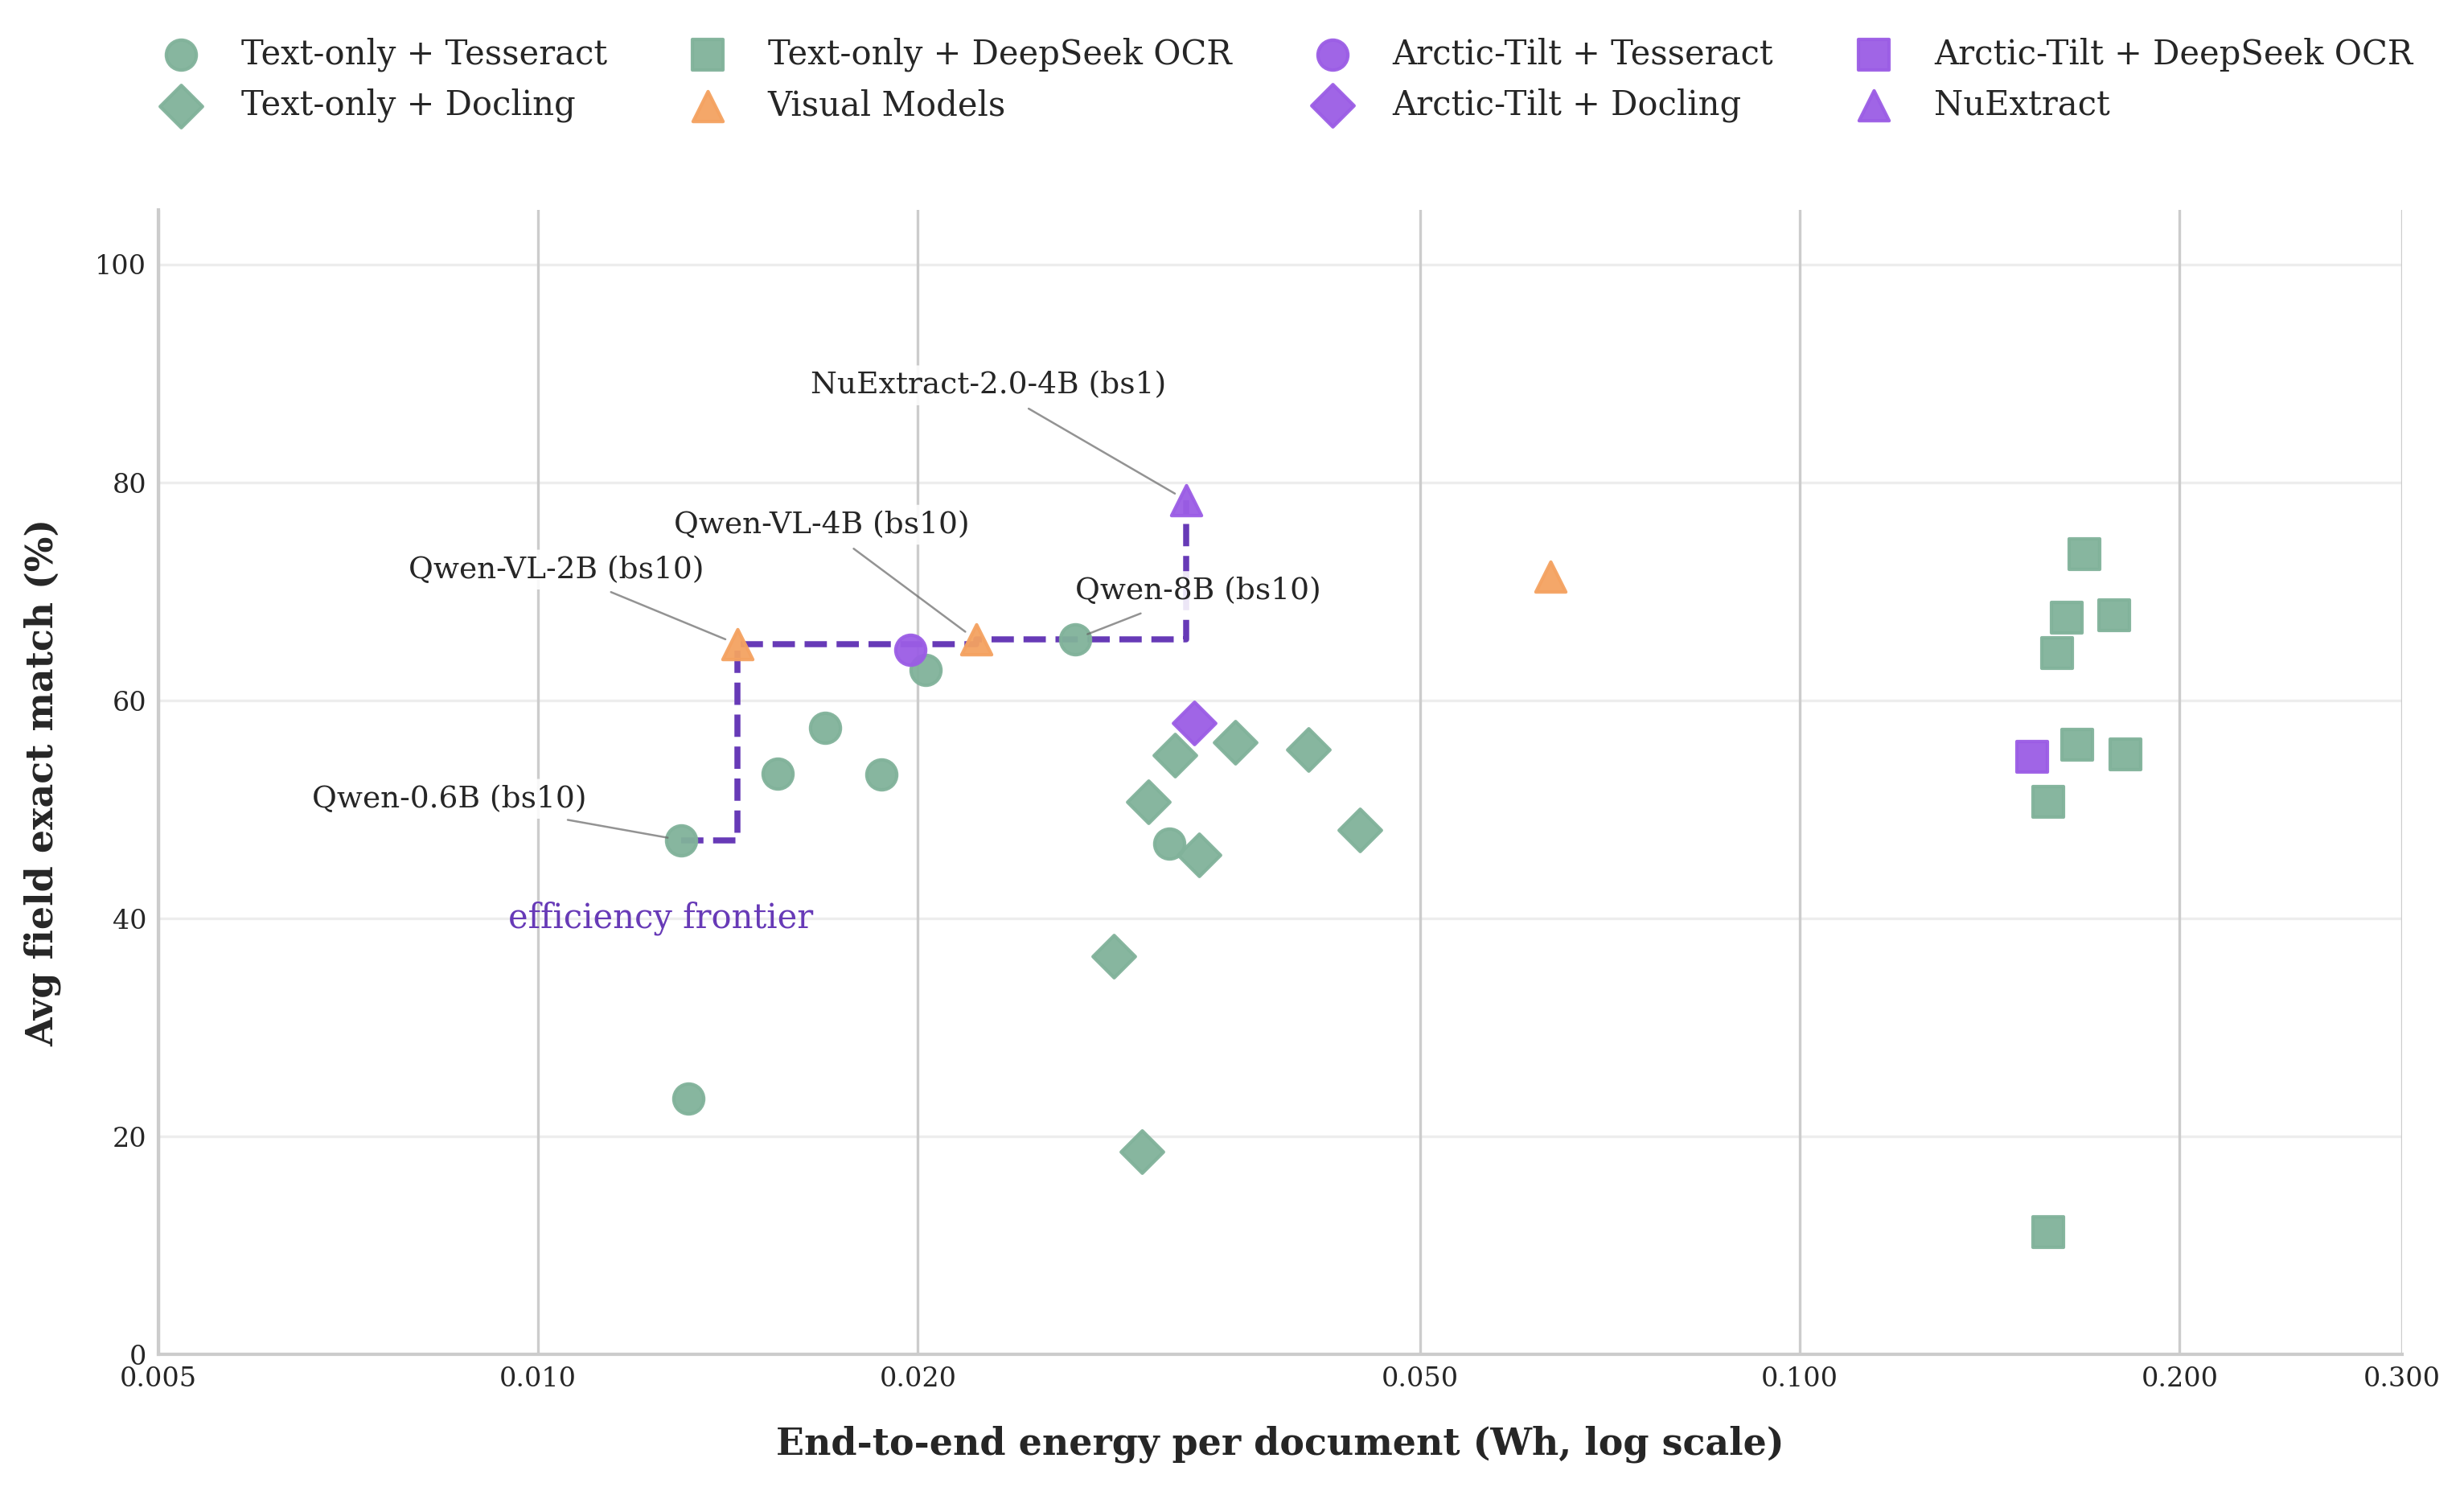

In [51]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd
import numpy as np


# 2. Pareto frontier
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )

    frontier_rows = []
    best_y = -float('inf')

    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']

    frontier_df = pd.DataFrame(frontier_rows)
    return frontier_df

# 3. Label cleanup helper
def clean_model_name(model, batch_size):
    name = str(model)

    replacements = {
        '-Instruct': '',
        '-2512': '',
        '-v0.3': '',
        'Qwen3-': '',
        'Llama-3.2-': '',
    }
    for old, new in replacements.items():
        name = name.replace(old, new)

    if str(model).startswith('Qwen'):
        if not name.startswith('Qwen'):
            name = 'Qwen-' + name
    elif str(model).startswith('Llama'):
        if not name.startswith('Llama'):
            name = 'Llama-' + name

    if batch_size != 20:
        name += f' (bs{int(batch_size)})'

    return name

fig, ax = plt.subplots(figsize=(12, 6.5))

if not df_plot.empty:
    # 4. Compute frontier
    frontier_df = get_pareto_frontier(df_plot)
    frontier_keys = set(zip(frontier_df['E2E_Energy_Doc'], frontier_df['Exact_Match']))

    # 5. Scatter all points by category
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(
                subset['E2E_Energy_Doc'],
                subset['Exact_Match'],
                color=style['color'],
                marker=style['marker'],
                s=80,
                label=category,
                zorder=4,
                alpha=0.95
            )

    # 6. Draw frontier
    if not frontier_df.empty:
        ax.step(
            frontier_df['E2E_Energy_Doc'],
            frontier_df['Exact_Match'],
            where='post',
            color='#673AB7',
            linestyle='--',
            linewidth=1.8,
            zorder=2
        )

    # Optional: keep just one subtle frontier label
    if not frontier_df.empty:
        first_row = frontier_df.iloc[0]
        ax.annotate(
            'efficiency frontier',
            xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']),
            xytext=(-6, -18),
            textcoords='offset points',
            color='#673AB7',
            fontsize=10,
            ha='center',
            va='top'
        )

# 7. Manual label placement for frontier points
frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
labeled_models = set()

# Hand-tuned offsets in points: (dx, dy)
custom_offsets = {
    'Qwen-0.6B (bs10)': (-28, 8),
    'Qwen-VL-2B (bs10)': (-10, 18),
    'Qwen-VL-4B (bs10)': (-2, 30),
    'Qwen-8B (bs10)': (0, 10),
    'NuExtract-2.0-4B (bs1)': (-6, 30),
}

for _, row in frontier_sorted.iterrows():
    x = row['E2E_Energy_Doc']
    y = row['Exact_Match']
    label = clean_model_name(row['Model'], row['Batch_Size'])

    if label in labeled_models:
        continue
    labeled_models.add(label)

    dx, dy = custom_offsets.get(label, (-18, 12))

    ax.annotate(
        label,
        xy=(x, y),
        xycoords='data',
        xytext=(dx, dy),
        textcoords='offset points',
        ha='right' if dx < 0 else 'left',
        va='bottom',
        fontsize=9,
        zorder=6,
        bbox=dict(
            boxstyle='round,pad=0.18',
            fc='white',
            ec='none',
            alpha=0.88,
        ),
        arrowprops=dict(
            arrowstyle='-',
            color='#666666',
            lw=0.6,
            alpha=0.7,
            shrinkA=2,
            shrinkB=4,
        ),
    )

# 9. Axis formatting
ax.set_xscale('log')
ax.set_xlabel('End-to-end energy per document (Wh, log scale)', fontsize=11, labelpad=10)
ax.set_ylabel('Avg field exact match (%)', fontsize=11, labelpad=10)

# Trim the x-axis to remove the empty space on the right
ax.set_xlim(left=0.005, right=0.3)
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='-', alpha=0.35)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 10. Legend
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(top=0.84)

# 11. Save
#plt.savefig(
#    'pareto_e2e_vrdu.pdf',
#    format='pdf',
#    bbox_inches='tight',
#    bbox_extra_artists=(lgd,)
#)
plt.show()

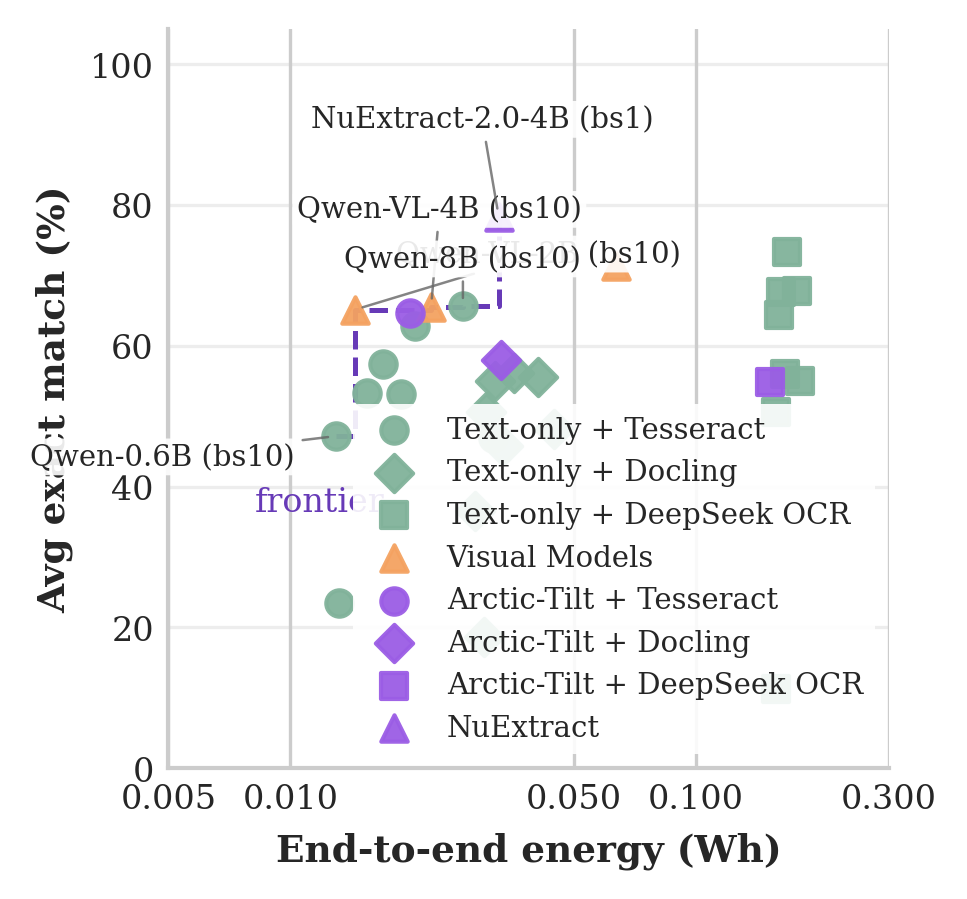

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. ACL-Specific Matplotlib Style Updates
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300
})

# 3. Pareto frontier
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )
    frontier_rows = []
    best_y = -float('inf')
    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']
    return pd.DataFrame(frontier_rows)

# 4. Label cleanup helper
def clean_model_name(model, batch_size):
    name = str(model)
    replacements = {'-Instruct': '', '-2512': '', '-v0.3': '', 'Qwen3-': '', 'Llama-3.2-': ''}
    for old, new in replacements.items():
        name = name.replace(old, new)
    if str(model).startswith('Qwen') and not name.startswith('Qwen'):
        name = 'Qwen-' + name
    elif str(model).startswith('Llama') and not name.startswith('Llama'):
        name = 'Llama-' + name
    if batch_size != 20:
        name += f' (bs{int(batch_size)})'
    return name

# 5. Optimized Figure Size for Single Column (3.1 inches wide)
fig, ax = plt.subplots(figsize=(3.1, 3.2))

if not df_plot.empty:
    frontier_df = get_pareto_frontier(df_plot)

    # Scatter points
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(subset['E2E_Energy_Doc'], subset['Exact_Match'], color=style['color'], marker=style['marker'], s=40, label=category, zorder=4, alpha=0.95)

    # Draw frontier
    if not frontier_df.empty:
        ax.step(frontier_df['E2E_Energy_Doc'], frontier_df['Exact_Match'], where='post', color='#673AB7', linestyle='--', linewidth=1.2, zorder=2)
        first_row = frontier_df.iloc[0]
        ax.annotate('frontier', xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']), xytext=(-4, -12), textcoords='offset points', color='#673AB7', fontsize=8, ha='center', va='top')

    # Manual label placement for frontier points
    frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
    labeled_models = set()

    # Hand-tuned offsets (dx, dy) targeting the cluster seen in the image
    custom_offsets = {
        'Arctic-Tilt (bs10)': (-15, 12),       # Push top-left
        'Qwen-4B (bs10)': (8, 12),            # Push top-right
        'Ministral-3-3B (bs10)': (-10, 20),      # Push straight right
        'Qwen-1.7B (bs10)': (-12, 0),         # Push down-right
        'Qwen-0.6B (bs10)': (-10, -5),         # Push far left
        # Fallbacks for other potential models
        'Qwen-VL-4B (bs10)': (2, 20),
        'Qwen-8B (bs10)': (0, 8),
        'NuExtract-2.0-4B (bs1)': (-4, 20),
    }

    for _, row in frontier_sorted.iterrows():
        x, y = row['E2E_Energy_Doc'], row['Exact_Match']
        label = clean_model_name(row['Model'], row['Batch_Size'])

        if label in labeled_models: continue
        labeled_models.add(label)

        dx, dy = custom_offsets.get(label, (10, 10))

        # Dynamic alignment based on the manual offset direction
        ha = 'left' if dx > 5 else ('right' if dx < -5 else 'center')
        va = 'bottom' if dy > 5 else ('top' if dy < -5 else 'center')

        ax.annotate(
            label,
            xy=(x, y),
            xycoords='data',
            xytext=(dx, dy),
            textcoords='offset points',
            ha=ha,
            va=va,
            fontsize=7,
            zorder=6,
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.9),
            arrowprops=dict(arrowstyle='-', color='#666666', lw=0.6, alpha=0.8, shrinkA=1, shrinkB=2)
        )

# 6. Axis formatting
ax.set_xscale('log')
ax.set_xlabel('End-to-end energy (Wh)', labelpad=4)
ax.set_ylabel('Avg exact match (%)', labelpad=4)

ax.set_xlim(left=0.005, right=0.3)
ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.3])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='-', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 7. Stacked, internal legend
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles, labels, loc='lower right', ncol=1, frameon=True, framealpha=0.9, edgecolor='none', fontsize=7)

# 8. Save
#plt.savefig('pareto_e2e_vrdu_acl.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [53]:
import pandas as pd
import numpy as np

# 1. Use the existing df_plot which already contains the exact filtered,
# unquantized, deduplicated VRDU models from your Pareto scatter plot.
df_table_base = df_plot.copy()

# 2. Determine OCR representation mapping directly from your plot categories
def determine_ocr(row):
    category = str(row.get('Category', ''))
    if category == 'Vision (no OCR)':
        return 'None (Vision)'
    elif category == 'Text-only + Tesseract':
        return 'Tesseract'
    elif category == 'Text-only + Docling':
        return 'Docling'
    elif category == 'Text-only + DeepSeek OCR':
        return 'DeepSeek'
    else:
        return 'None (Base)'

df_table_base['OCR'] = df_table_base.apply(determine_ocr, axis=1)

# 3. Calculate just the isolated OCR Energy for transparency in the table
# (df_plot already calculated E2E_Energy_Doc for us)
def extract_ocr_energy(row):
    task = str(row['Task']).lower()
    modality = str(row['Modality'])
    model_name = str(row['Model']).lower()

    if modality == 'Text-Only' or 'arctic' in model_name:
        ocr_task = task if task in ['docling', 'deepseek'] else 'tesseract'
        return get_ocr_energy_per_doc('VRDU', ocr_task)
    return 0.0

df_table_base['OCR_Energy_Wh'] = df_table_base.apply(extract_ocr_energy, axis=1)

# Ensure metrics exist in case of merge discrepancies
for col in ['Fuzzy_Match', 'F1_Score']:
    if col not in df_table_base.columns:
        df_table_base[col] = 0.0

# 4. Filter and rename columns for the final table
columns_map = {
    'Model': 'Model',
    'Batch_Size': 'Batch Size',
    'OCR': 'OCR',
    'Exact_Match': 'Exact Match (\\%)',
    'Fuzzy_Match': 'Fuzzy Match (\\%)',
    'F1_Score': 'F1 Score (\\%)',
    'OCR_Energy_Wh': 'OCR Energy (Wh)',
    'E2E_Energy_Doc': 'E2E Energy (Wh)'
}

df_table = df_table_base[list(columns_map.keys())].rename(columns=columns_map)

# 5. Sort the table
df_table = df_table.sort_values(by=['Model', 'Batch Size', 'OCR']).reset_index(drop=True)

# Define exact string formatting for each column
# This forces 1 decimal for percentages, 4 for energy, and replaces NaNs with "-"
formatters = {
    'Exact Match (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'Fuzzy Match (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'F1 Score (\\%)':    lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'OCR Energy (Wh)':   lambda x: f"{x:.4f}" if pd.notna(x) else "-",
    'E2E Energy (Wh)':   lambda x: f"{x:.4f}" if pd.notna(x) else "-"
}

# 6. Generate and print the LaTeX code
latex_code = df_table.to_latex(
    index=False,
    caption="Detailed Benchmarking Results for VRDU Dataset (Pareto Plot Configurations)",
    label="tab:vrdu_plot_results",
    column_format="llcccccc",
    formatters=formatters, # Apply the strict formatting rules here
    escape=False
)

print(latex_code)


\begin{table}
\caption{Detailed Benchmarking Results for VRDU Dataset (Pareto Plot Configurations)}
\label{tab:vrdu_plot_results}
\begin{tabular}{llcccccc}
\toprule
Model & Batch Size & OCR & Exact Match (\%) & Fuzzy Match (\%) & F1 Score (\%) & OCR Energy (Wh) & E2E Energy (Wh) \\
\midrule
Arctic-Tilt & 10 & None (Base) & 54.8 & NaN & NaN & 0.1528 & 0.1528 \\
Arctic-Tilt & 10 & None (Base) & 57.9 & NaN & NaN & 0.0259 & 0.0331 \\
Arctic-Tilt & 10 & None (Base) & 64.6 & NaN & NaN & 0.0097 & 0.0197 \\
Llama-3.2-1B-Instruct & 10 & DeepSeek & 11.2 & 13.4 & 9.8 & 0.1528 & 0.1575 \\
Llama-3.2-1B-Instruct & 10 & Docling & 18.6 & 31.2 & 17.6 & 0.0259 & 0.0301 \\
Llama-3.2-1B-Instruct & 10 & Tesseract & 23.5 & 30.9 & 21.7 & 0.0097 & 0.0132 \\
Llama-3.2-3B-Instruct & 10 & DeepSeek & 55.9 & 77.5 & 57.4 & 0.1528 & 0.1659 \\
Llama-3.2-3B-Instruct & 10 & Docling & 45.8 & 71.6 & 45.4 & 0.0259 & 0.0334 \\
Llama-3.2-3B-Instruct & 10 & Tesseract & 53.2 & 73.9 & 53.4 & 0.0097 & 0.0187 \\
Ministral-3-3B-I

In [54]:
# 1. Constants
TARGET_DATASET = 'Kleister NDA'
TEST_SET_SIZES = {'VRDU': 500, 'Kleister NDA': 337}

# 2. Filter for Target Dataset & Unquantized Models Only
df_plot = df_all[df_all['Dataset'] == TARGET_DATASET].copy()

# Keep explicit 'noquant', drop explicit 'quant', keep standalone paths (Arctic/NuExtract)
def is_unquantized(path):
    path_str = str(path).lower()
    if 'noquant' in path_str: return True
    if 'quant' in path_str and 'noquant' not in path_str: return False
    return True # Keep standalone benchmarks safely

unquant_mask = df_plot['File_Path'].apply(is_unquantized)
df_plot = df_plot[unquant_mask].copy()

# 3. Calculate End-to-End Energy per Document
def calc_end_to_end_energy(row):
    base_energy_per_doc = row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1)
    modality = str(row['Modality'])
    task = str(row['Task']).lower()
    model_name = str(row['Model']).lower()

    # Add OCR energy dynamically (Assuming Tesseract as default overhead for Arctic-Tilt)
    if modality == 'Text-Only' or 'arctic' in model_name:
        ocr_task = task if task in ['docling', 'deepseek'] else 'tesseract'
        ocr_overhead = get_ocr_energy_per_doc(row['Dataset'], ocr_task)
        return base_energy_per_doc + ocr_overhead

    return base_energy_per_doc

if not df_plot.empty:
    df_plot['E2E_Energy_Doc'] = df_plot.apply(calc_end_to_end_energy, axis=1)

if not df_plot.empty:
    df_plot['Category'] = df_plot.apply(categorize_model, axis=1)
    df_plot = df_plot[df_plot['Category'] != 'Other']

    # 5. PRIORITIZE BATCH SIZE 20
    df_plot['is_bs_20'] = df_plot['Batch_Size'] == 20
    df_plot = df_plot.sort_values(
        by=['Model', 'Category', 'is_bs_20', 'Batch_Size', 'Exact_Match'],
        ascending=[True, True, False, False, False]
    )

    # Deduplicate to keep only the best/preferred configuration per model-category
    df_plot = df_plot.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)

# --- ADD THIS BLOCK TO FIND MISSING BS=20 MODELS ---
missing_bs20 = df_plot[df_plot['is_bs_20'] == False]
if not missing_bs20.empty:
    print("Models missing Batch Size 20 (falling back to other sizes):")
    for index, row in missing_bs20.iterrows():
        print(f"- Model: {row['Model']} | Category: {row['Category']} | Fallback Batch Size Used: {row['Batch_Size']}")
else:
    print("All plotted models have a Batch Size 20 result available.")

Models missing Batch Size 20 (falling back to other sizes):
- Model: Arctic-Tilt | Category: Arctic-Tilt + DeepSeek OCR | Fallback Batch Size Used: 10
- Model: Arctic-Tilt | Category: Arctic-Tilt + Docling | Fallback Batch Size Used: 10
- Model: Arctic-Tilt | Category: Arctic-Tilt + Tesseract | Fallback Batch Size Used: 10
- Model: Llama-3.2-1B-Instruct | Category: Text-only + DeepSeek OCR | Fallback Batch Size Used: 10
- Model: Llama-3.2-1B-Instruct | Category: Text-only + Docling | Fallback Batch Size Used: 10
- Model: Llama-3.2-1B-Instruct | Category: Text-only + Tesseract | Fallback Batch Size Used: 10
- Model: Llama-3.2-3B-Instruct | Category: Text-only + DeepSeek OCR | Fallback Batch Size Used: 10
- Model: Llama-3.2-3B-Instruct | Category: Text-only + Docling | Fallback Batch Size Used: 10
- Model: Llama-3.2-3B-Instruct | Category: Text-only + Tesseract | Fallback Batch Size Used: 10
- Model: Ministral-3-3B-Instruct-2512 | Category: Text-only + DeepSeek OCR | Fallback Batch Size 

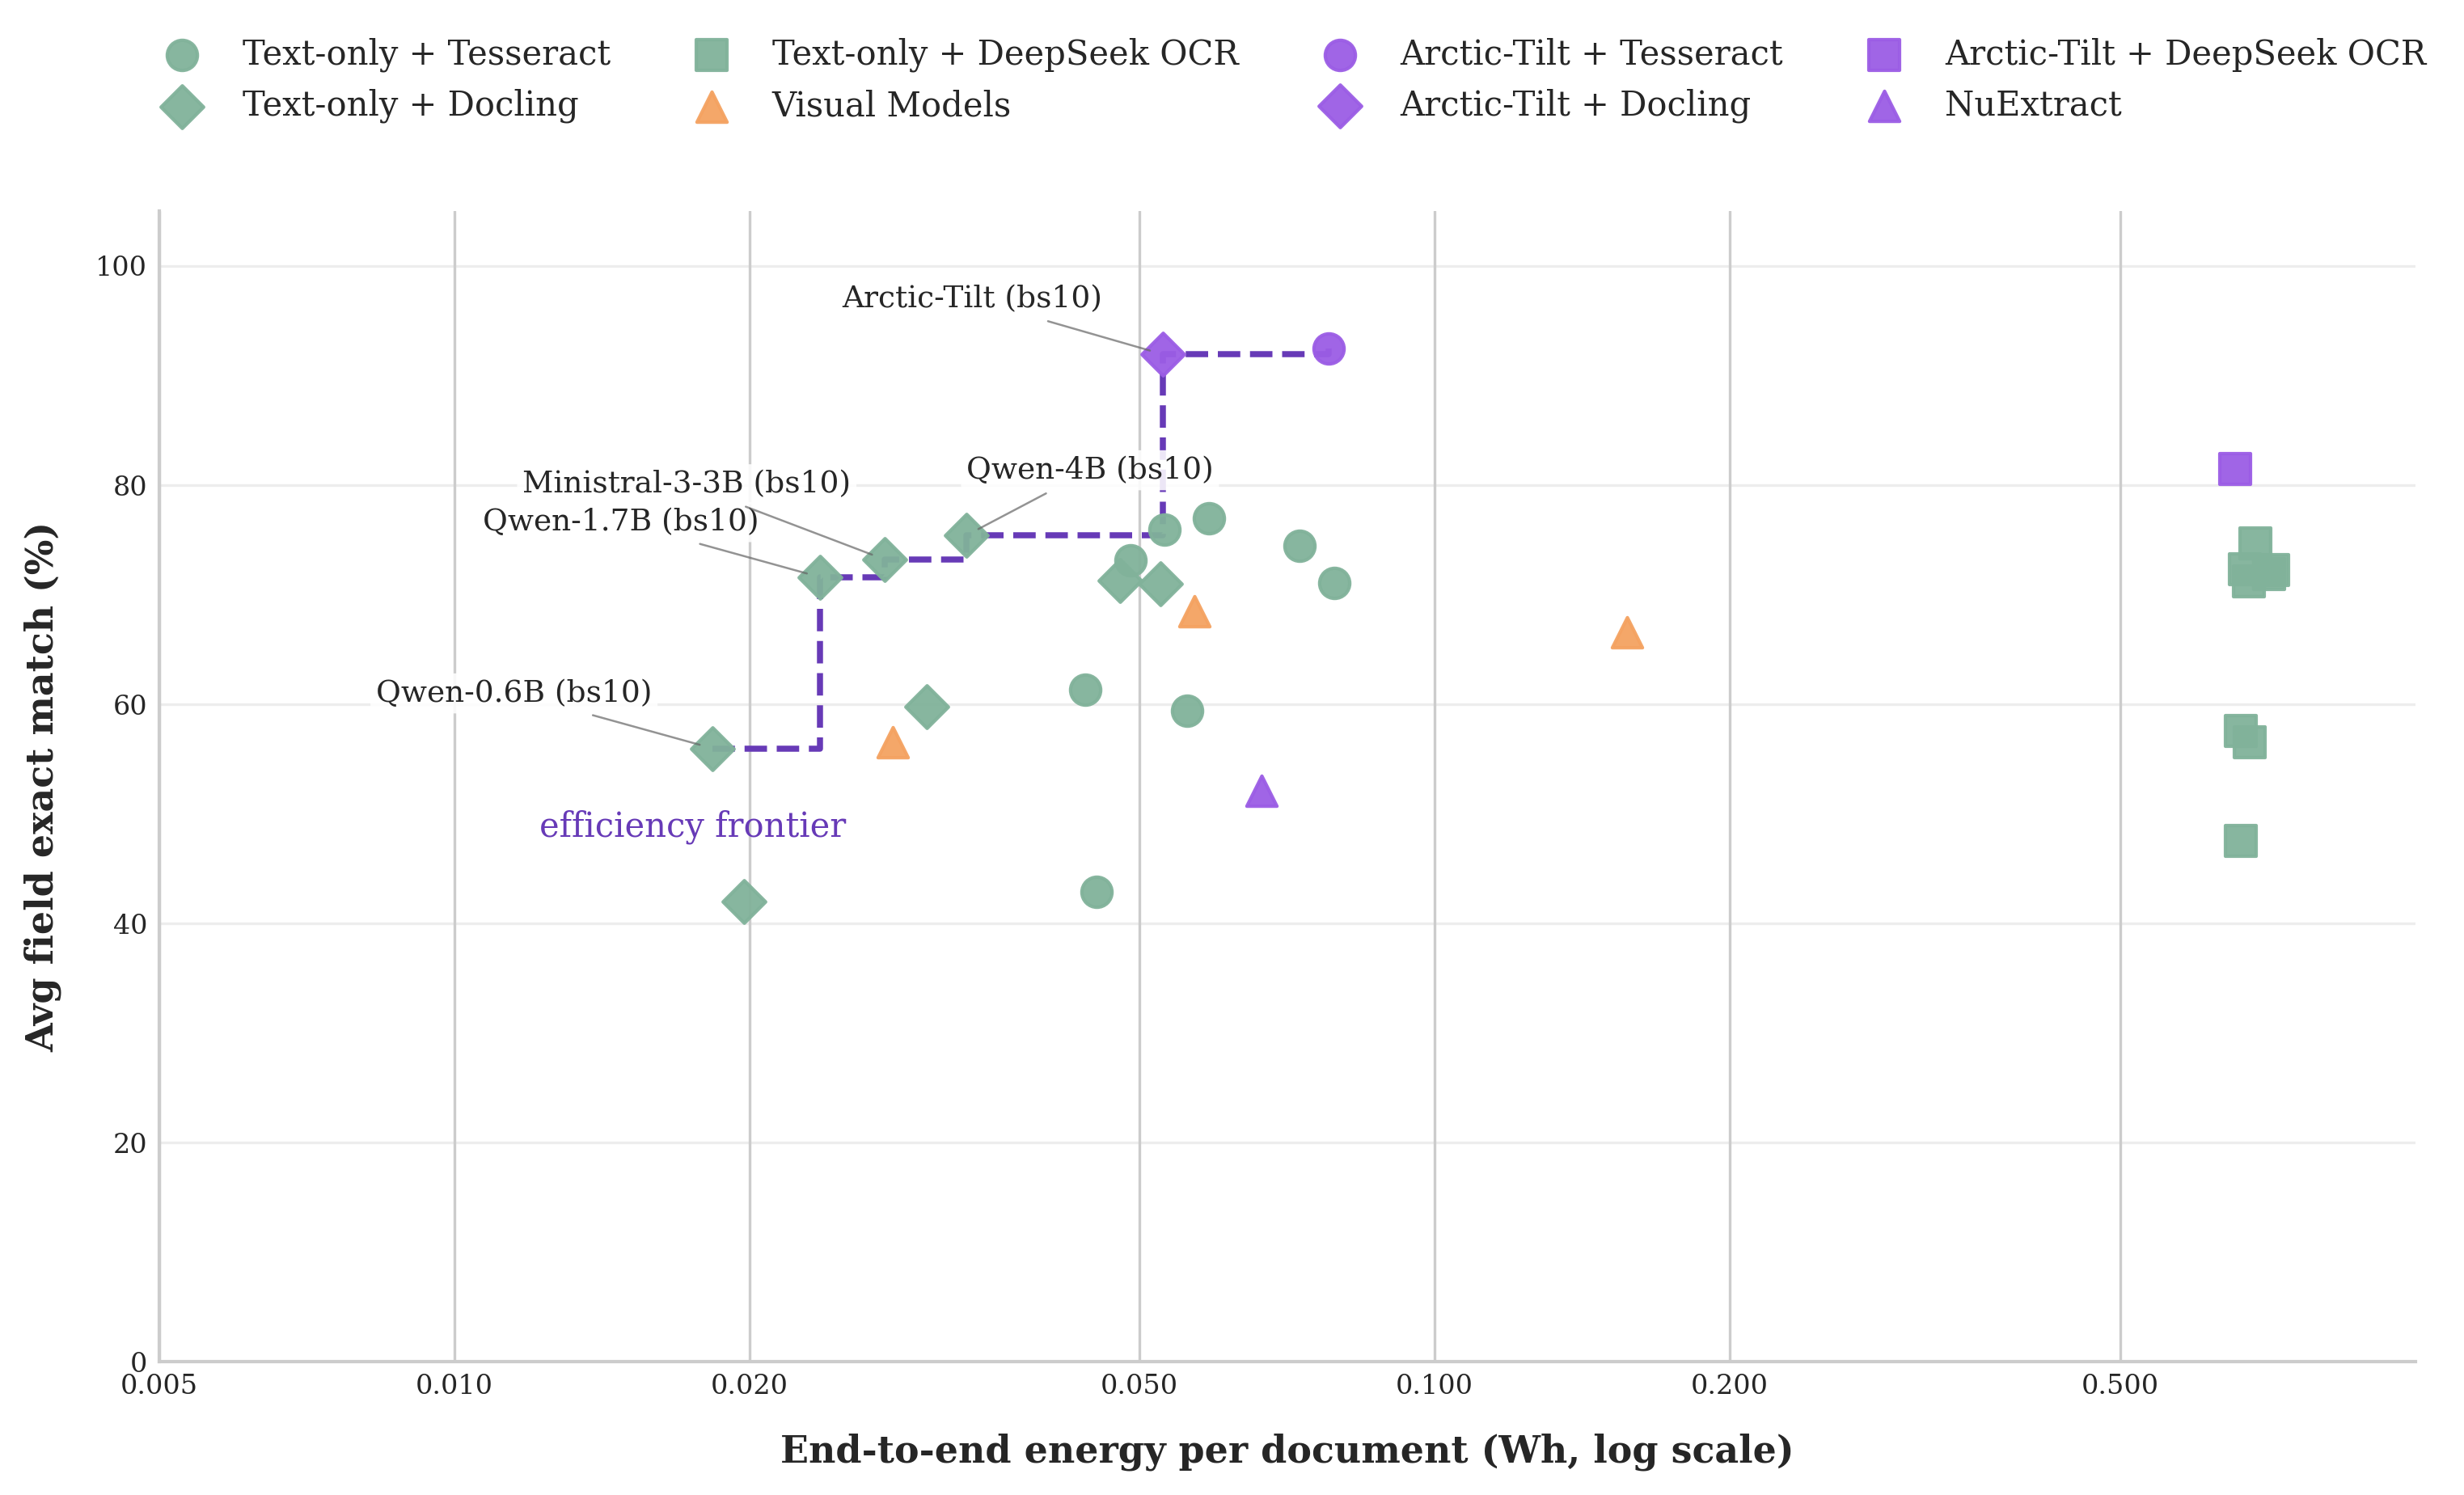

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Colors and markers


# 2. Pareto frontier (Updated to return DataFrame like VRDU script)
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )

    frontier_rows = []
    best_y = -float('inf')

    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']

    frontier_df = pd.DataFrame(frontier_rows)
    return frontier_df

# 3. Label cleanup helper
def clean_model_name(model, batch_size):
    name = str(model)

    replacements = {
        '-Instruct': '',
        '-2512': '',
        '-v0.3': '',
        'Qwen3-': '',
        'Llama-3.2-': '',
    }
    for old, new in replacements.items():
        name = name.replace(old, new)

    if str(model).startswith('Qwen'):
        if not name.startswith('Qwen'):
            name = 'Qwen-' + name
    elif str(model).startswith('Llama'):
        if not name.startswith('Llama'):
            name = 'Llama-' + name

    if batch_size != 20:
        name += f' (bs{int(batch_size)})'

    return name

fig, ax = plt.subplots(figsize=(12, 6.5))

if not df_plot.empty:
    # 4. Compute frontier
    frontier_df = get_pareto_frontier(df_plot)

    # 5. Scatter all points by category
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(
                subset['E2E_Energy_Doc'],
                subset['Exact_Match'],
                color=style['color'],
                marker=style['marker'],
                s=80,
                label=category,
                zorder=4,
                alpha=0.95
            )

    # 6. Draw frontier
    if not frontier_df.empty:
        ax.step(
            frontier_df['E2E_Energy_Doc'],
            frontier_df['Exact_Match'],
            where='post',
            color='#673AB7',
            linestyle='--',
            linewidth=1.8,
            zorder=2
        )

        # Subtle frontier label
        first_row = frontier_df.iloc[0]
        ax.annotate(
            'efficiency frontier',
            xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']),
            xytext=(-6, -18),
            textcoords='offset points',
            color='#673AB7',
            fontsize=10,
            ha='center',
            va='top'
        )

    # 7. Manual label placement for frontier points (Replacing adjust_text)
    frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
    labeled_models = set()

    # Hand-tuned offsets in points: (dx, dy)
    # TODO: Add your Kleister NDA specific models and adjust offsets here
    custom_offsets = {
        'Qwen-4B (bs10)': (0, 15),
        'Ministral-3-3B (bs10)': (-10, 18),
        'Qwen-VL-4B (bs10)': (-2, 30),
        'Qwen-8B (bs10)': (0, 10),
        'NuExtract-2.0-4B (bs1)': (-6, 30),
    }

    for _, row in frontier_sorted.iterrows():
        x = row['E2E_Energy_Doc']
        y = row['Exact_Match']
        label = clean_model_name(row['Model'], row['Batch_Size'])

        if label in labeled_models:
            continue
        labeled_models.add(label)

        dx, dy = custom_offsets.get(label, (-18, 12))

        ax.annotate(
            label,
            xy=(x, y),
            xycoords='data',
            xytext=(dx, dy),
            textcoords='offset points',
            ha='right' if dx < 0 else 'left',
            va='bottom',
            fontsize=9,
            zorder=6,
            bbox=dict(
                boxstyle='round,pad=0.18',
                fc='white',
                ec='none',
                alpha=0.88,
            ),
            arrowprops=dict(
                arrowstyle='-',
                color='#666666',
                lw=0.6,
                alpha=0.7,
                shrinkA=2,
                shrinkB=4,
            ),
        )

# 8. Axis formatting (Maintained Kleister NDA settings)
ax.set_xscale('log')
ax.set_xlabel('End-to-end energy per document (Wh, log scale)', fontsize=11, labelpad=10)
ax.set_ylabel('Avg field exact match (%)', fontsize=11, labelpad=10)

# Extended upper bound for Kleister NDA documents
ax.set_xlim(left=0.005, right=1) # slightly extended right to leave room for right-aligned labels
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='-', alpha=0.35)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 9. Legend
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(top=0.84)

# 10. Save
#plt.savefig(
#    'pareto_e2e_kleister.pdf',
#    format='pdf',
#    bbox_inches='tight',
#    bbox_extra_artists=(lgd,)
#)
plt.show()

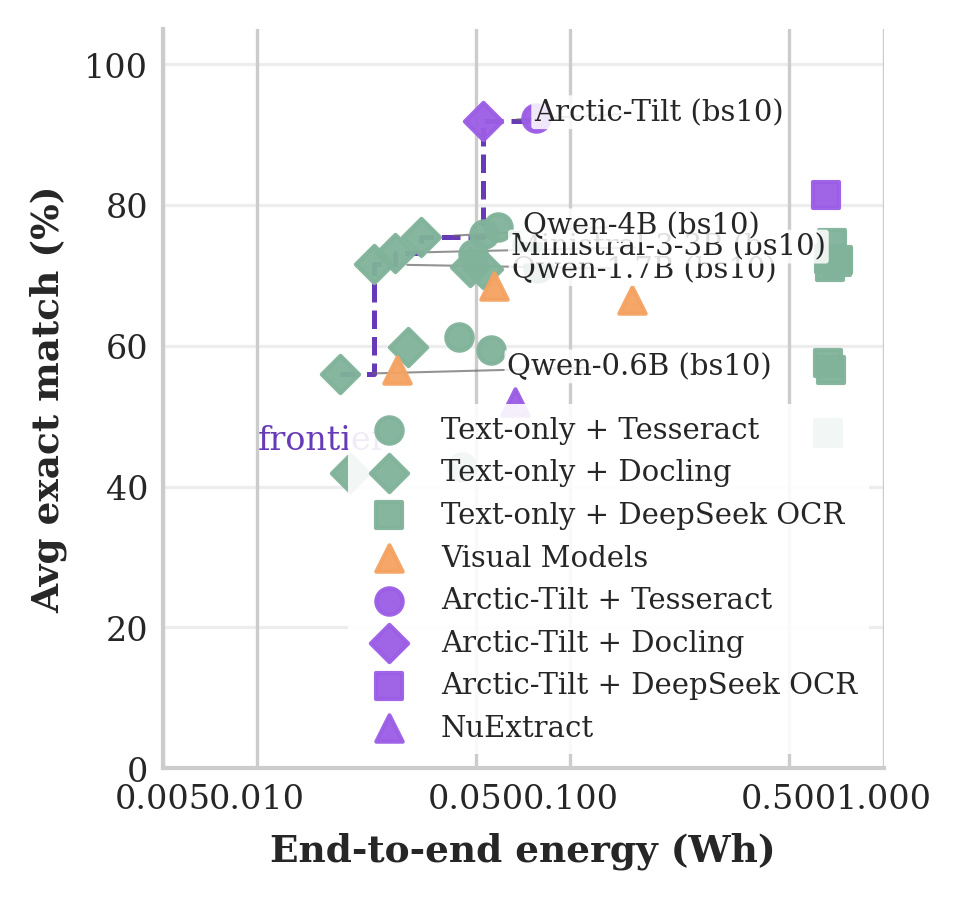

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text

# 1. ACL-Specific Matplotlib Style Updates
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300
})

# 3. Pareto frontier
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )
    frontier_rows = []
    best_y = -float('inf')
    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']
    return pd.DataFrame(frontier_rows)

# 4. Label cleanup helper
def clean_model_name(model, batch_size):
    name = str(model)
    replacements = {'-Instruct': '', '-2512': '', '-v0.3': '', 'Qwen3-': '', 'Llama-3.2-': ''}
    for old, new in replacements.items():
        name = name.replace(old, new)
    if str(model).startswith('Qwen') and not name.startswith('Qwen'):
        name = 'Qwen-' + name
    elif str(model).startswith('Llama') and not name.startswith('Llama'):
        name = 'Llama-' + name
    if batch_size != 20:
        name += f' (bs{int(batch_size)})'
    return name

# 5. Optimized Figure Size for Single Column (3.1 inches wide)
fig, ax = plt.subplots(figsize=(3.1, 3.2))

if not df_plot.empty:
    frontier_df = get_pareto_frontier(df_plot)

    # Scatter points
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(subset['E2E_Energy_Doc'], subset['Exact_Match'], color=style['color'], marker=style['marker'], s=40, label=category, zorder=4, alpha=0.95)

    # Draw frontier
    if not frontier_df.empty:
        ax.step(frontier_df['E2E_Energy_Doc'], frontier_df['Exact_Match'], where='post', color='#673AB7', linestyle='--', linewidth=1.2, zorder=2)
        first_row = frontier_df.iloc[0]
        ax.annotate('frontier', xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']), xytext=(-4, -12), textcoords='offset points', color='#673AB7', fontsize=8, ha='center', va='top')

    # Automatic label placement using adjustText
    frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
    labeled_models = set()
    texts = []

    for _, row in frontier_sorted.iterrows():
        x, y = row['E2E_Energy_Doc'], row['Exact_Match']
        label = clean_model_name(row['Model'], row['Batch_Size'])
        if label in labeled_models: continue
        labeled_models.add(label)

        texts.append(ax.text(x, y, label, fontsize=7, zorder=6,
                             bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.85)))

    # Let the library auto-resolve overlaps with increased shrink to prevent strike-throughs
    adjust_text(texts,
                ax=ax,
                force_text=(0.5, 1.0),
                expand_points=(1.2, 1.5),
                arrowprops=dict(arrowstyle='-', color='#666666', lw=0.5, alpha=0.7, shrinkA=8, shrinkB=8))

# 6. Axis formatting (Extended for Kleister)
ax.set_xscale('log')
ax.set_xlabel('End-to-end energy (Wh)', labelpad=4)
ax.set_ylabel('Avg exact match (%)', labelpad=4)

ax.set_xlim(left=0.005, right=1.0)
ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5, 1.0])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='-', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 7. Stacked, internal legend
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles, labels, loc='lower right', ncol=1, frameon=True, framealpha=0.9, edgecolor='none', fontsize=7)

# 8. Save
#plt.savefig('pareto_e2e_kleister_acl.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [57]:
import pandas as pd
import numpy as np

# 1. Use the existing df_plot which already contains the exact filtered,
# unquantized, deduplicated Kleister NDA models from your Pareto scatter plot.
df_table_base = df_plot.copy()

# 2. Determine OCR representation mapping directly from your plot categories
def determine_ocr(row):
    category = str(row.get('Category', ''))
    if category == 'Vision (no OCR)':
        return 'None (Vision)'
    elif category == 'Text-only + Tesseract':
        return 'Tesseract'
    elif category == 'Text-only + Docling':
        return 'Docling'
    elif category == 'Text-only + DeepSeek OCR':
        return 'DeepSeek'
    else:
        return 'None (Base)'

df_table_base['OCR'] = df_table_base.apply(determine_ocr, axis=1)

# 3. Calculate just the isolated OCR Energy for transparency in the table
def extract_ocr_energy(row):
    task = str(row['Task']).lower()
    modality = str(row['Modality'])
    model_name = str(row['Model']).lower()

    if modality == 'Text-Only' or 'arctic' in model_name:
        ocr_task = task if task in ['docling', 'deepseek'] else 'tesseract'
        # FIXED: Removed the underscore to match your function's expected string
        energy = get_ocr_energy_per_doc('Kleister NDA', ocr_task)
        # Safeguard against the function unexpectedly returning None
        return energy if energy is not None else 0.0
    return 0.0

df_table_base['OCR_Energy_Wh'] = df_table_base.apply(extract_ocr_energy, axis=1)

# Ensure metrics exist in case of merge discrepancies
for col in ['Fuzzy_Match', 'F1_Score']:
    if col not in df_table_base.columns:
        df_table_base[col] = np.nan

# 4. Filter and rename columns for the final table
columns_map = {
    'Model': 'Model',
    'Batch_Size': 'Batch Size',
    'OCR': 'OCR',
    'Exact_Match': 'Exact Match (\\%)',
    'Fuzzy_Match': 'Fuzzy Match (\\%)',
    'F1_Score': 'F1 Score (\\%)',
    'OCR_Energy_Wh': 'OCR Energy (Wh)',
    'E2E_Energy_Doc': 'E2E Energy (Wh)'
}

df_table = df_table_base[list(columns_map.keys())].rename(columns=columns_map)

# 5. Sort the table
df_table = df_table.sort_values(by=['Model', 'Batch Size', 'OCR']).reset_index(drop=True)

# 6. Define exact string formatting for each column
formatters = {
    'Exact Match (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'Fuzzy Match (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'F1 Score (\\%)':    lambda x: f"{x:.1f}" if pd.notna(x) else "-",
    'OCR Energy (Wh)':   lambda x: f"{x:.4f}" if pd.notna(x) else "-",
    'E2E Energy (Wh)':   lambda x: f"{x:.4f}" if pd.notna(x) else "-"
}

# 7. Generate and print the LaTeX code
latex_code = df_table.to_latex(
    index=False,
    caption="Detailed Benchmarking Results for Kleister NDA Dataset (Pareto Plot Configurations)",
    label="tab:kleister_nda_plot_results",
    column_format="llcccccc",
    formatters=formatters,
    na_rep="-", # FIXED: Forces Pandas to print '-' instead of 'NaN' for missing data
    escape=False
)

print(latex_code)

\begin{table}
\caption{Detailed Benchmarking Results for Kleister NDA Dataset (Pareto Plot Configurations)}
\label{tab:kleister_nda_plot_results}
\begin{tabular}{llcccccc}
\toprule
Model & Batch Size & OCR & Exact Match (\%) & Fuzzy Match (\%) & F1 Score (\%) & OCR Energy (Wh) & E2E Energy (Wh) \\
\midrule
Arctic-Tilt & 10 & None (Base) & 81.5 & - & - & 0.6543 & 0.6554 \\
Arctic-Tilt & 10 & None (Base) & 91.9 & - & - & 0.0130 & 0.0528 \\
Arctic-Tilt & 10 & None (Base) & 92.4 & - & - & 0.0383 & 0.0779 \\
Llama-3.2-1B-Instruct & 10 & DeepSeek & 47.6 & 70.7 & 58.4 & 0.6543 & 0.6635 \\
Llama-3.2-1B-Instruct & 10 & Docling & 42.0 & 64.6 & 53.2 & 0.0130 & 0.0198 \\
Llama-3.2-1B-Instruct & 10 & Tesseract & 42.9 & 65.2 & 53.9 & 0.0383 & 0.0452 \\
Llama-3.2-3B-Instruct & 10 & DeepSeek & 56.5 & 74.9 & 66.2 & 0.6543 & 0.6784 \\
Llama-3.2-3B-Instruct & 10 & Docling & 59.8 & 78.6 & 68.7 & 0.0130 & 0.0303 \\
Llama-3.2-3B-Instruct & 10 & Tesseract & 59.4 & 77.2 & 68.6 & 0.0383 & 0.0559 \\
Ministral-3

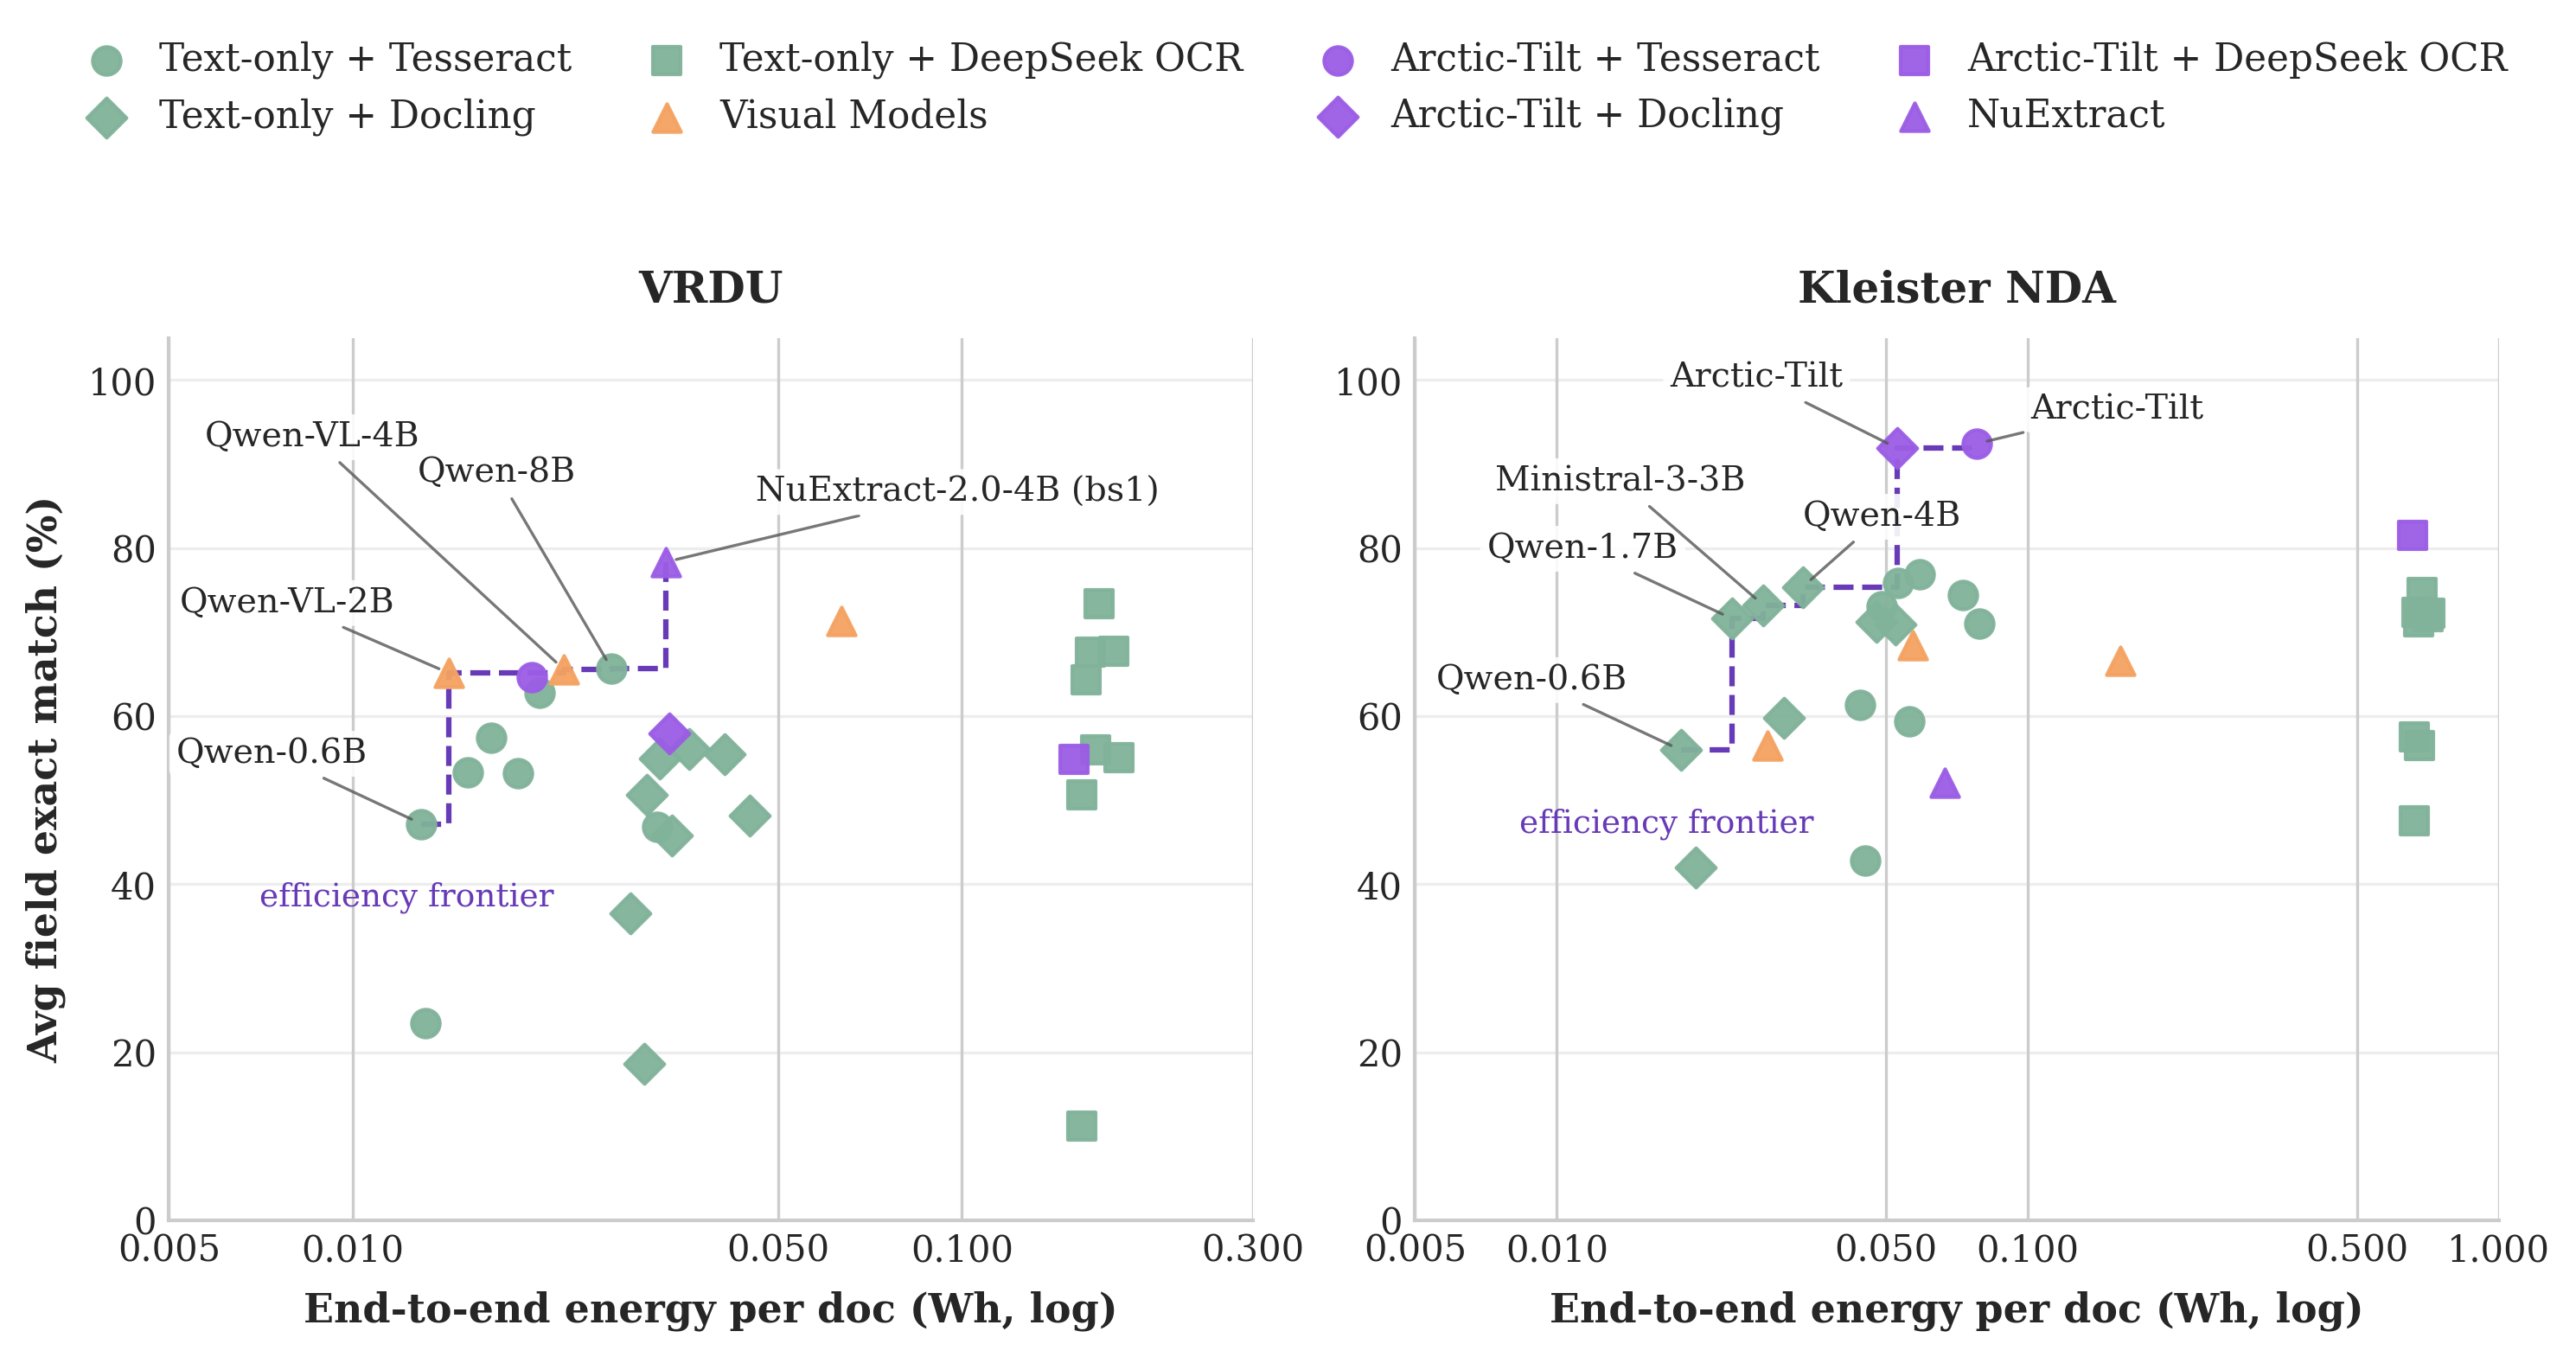

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 2. Reusable Helper Functions
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )
    frontier_rows = []
    best_y = -float('inf')
    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']
    return pd.DataFrame(frontier_rows)

def clean_model_name(model, batch_size):
    name = str(model)
    replacements = {'-Instruct': '', '-2512': '', '-v0.3': '', 'Qwen3-': '', 'Llama-3.2-': ''}
    for old, new in replacements.items():
        name = name.replace(old, new)
    if str(model).startswith('Qwen') and not name.startswith('Qwen'): name = 'Qwen-' + name
    elif str(model).startswith('Llama') and not name.startswith('Llama'): name = 'Llama-' + name
    if batch_size not in [10, 20]:
        name += f' (bs{int(batch_size)})'
    return name

def prep_dataset(df_all, target_dataset):
    df_plot = df_all[df_all['Dataset'] == target_dataset].copy()

    def is_unquantized(path):
        path_str = str(path).lower()
        if 'noquant' in path_str: return True
        if 'quant' in path_str and 'noquant' not in path_str: return False
        return True
    df_plot = df_plot[df_plot['File_Path'].apply(is_unquantized)].copy()

    if not df_plot.empty:
        df_plot['E2E_Energy_Doc'] = df_plot.apply(calc_end_to_end_energy, axis=1)
        df_plot['Category'] = df_plot.apply(categorize_model, axis=1)
        df_plot = df_plot[df_plot['Category'] != 'Other']

        target_bs = 10 if target_dataset == 'VRDU' else 20
        df_plot['is_target_bs'] = df_plot['Batch_Size'] == target_bs
        df_plot = df_plot.sort_values(
            by=['Model', 'Category', 'is_target_bs', 'Batch_Size', 'Exact_Match'],
            ascending=[True, True, False, False, False]
        )
        df_plot = df_plot.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)
    return df_plot

# 3. Expanded Offsets to Prevent Overlap
custom_offsets = {
    # VRDU Offsets
    'Qwen-0.6B (bs10)': (-30, 20),       # Left and up
    'Qwen-VL-2B (bs10)': (-60, 50),      # Pushed VERY high and left to clear the middle
    'Qwen-8B': (-10, 50),         #
    'NuExtract-2.0-4B (bs1)': (25, 15),  # Pushed right to stop crossing the dashed line

    # Specific offset for the blue Tesseract point
    ('Arctic-Tilt', 'Arctic-Tilt + Tesseract'): (15, 5), # Pushes it right and slightly down

    # Kleister NDA Offsets
    'Qwen-0.6B (bs20)': (-35, 15),       # Left and up
    'Ministral-3-3B': (-5, 30),  # Pushed VERY high and left
    'Qwen-4B': (0, 15),         # Pushed DOWN and right to completely separate from Ministral
    'Arctic-Tilt (bs10)': (25, 10),      # Pushed right
    'Arctic-Tilt (bs20)': (25, 10),      # Fallback depending on exact naming
    'Qwen-VL-4B': (-40, 60)       # High and left fallback
}

# 4. Adjusted Figure Size for better Aspect Ratio
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
datasets = ['VRDU', 'Kleister NDA']

# 5. Plotting Loop
for i, dataset in enumerate(datasets):
    ax = axes[i]
    df_plot = prep_dataset(df_all, dataset)

    if df_plot.empty:
        continue

    frontier_df = get_pareto_frontier(df_plot)

    # Scatter points (increased marker size back slightly)
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(
                subset['E2E_Energy_Doc'], subset['Exact_Match'],
                color=style['color'], marker=style['marker'], s=60,
                label=category, zorder=4, alpha=0.95
            )

    # Draw frontier
    if not frontier_df.empty:
        ax.step(
            frontier_df['E2E_Energy_Doc'], frontier_df['Exact_Match'],
            where='post', color='#673AB7', linestyle='--', linewidth=1.5, zorder=2
        )
        first_row = frontier_df.iloc[0]
        ax.annotate(
            'efficiency frontier',
            xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']),
            xytext=(-4, -16), textcoords='offset points', color='#673AB7',
            fontsize=9, ha='center', va='top' # Increased font
        )

    # Add labels
    frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
    labeled_models = set()

    for _, row in frontier_sorted.iterrows():
        x, y = row['E2E_Energy_Doc'], row['Exact_Match']
        label = clean_model_name(row['Model'], row['Batch_Size'])

        # Create a unique ID using BOTH the label and the category
        unique_id = (label, row['Category'])

        if unique_id in labeled_models: continue
        labeled_models.add(unique_id)

        # Look for the exact tuple first, fallback to just the label, then fallback to default
        if unique_id in custom_offsets:
            dx, dy = custom_offsets[unique_id]
        else:
            dx, dy = custom_offsets.get(label, (-15, 15))

        ax.annotate(
            label, xy=(x, y), xycoords='data', xytext=(dx, dy), textcoords='offset points',
            ha='right' if dx < 0 else 'left', va='bottom',
            fontsize=9.5, # Significantly increased font size
            zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9),
            arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8, alpha=0.8, shrinkA=1, shrinkB=3)
        )

    # Axis Formatting (Larger fonts)
    ax.set_title(dataset, fontsize=12, fontweight='bold', pad=10)
    ax.set_xscale('log')
    ax.set_xlabel('End-to-end energy per doc (Wh, log)', fontsize=11, labelpad=6)
    ax.tick_params(axis='both', labelsize=10)

    if i == 0:
        ax.set_ylabel('Avg field exact match (%)', fontsize=11, labelpad=6)
        ax.set_xlim(left=0.005, right=0.3)
        ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.3])
    else:
        ax.set_xlim(left=0.005, right=1.0)
        ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5, 1.0])

    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='-', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 6. Shared Legend (Moved down, larger text)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = fig.legend(
    by_label.values(), by_label.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.96), # Moved down from 1.05
    ncol=4, frameon=False,
    fontsize=10.5, # Increased font
    handletextpad=0.4, columnspacing=1.5
)

# 7. Final Adjustments and Save
fig.tight_layout()
# Adjusted top to remove excess whitespace, increased wspace for readability
fig.subplots_adjust(top=0.83, bottom=0.15, wspace=0.15)

plt.savefig(
    'pareto_e2e.pdf',
    format='pdf',
    bbox_inches='tight',
    bbox_extra_artists=(lgd,)
)
plt.show()

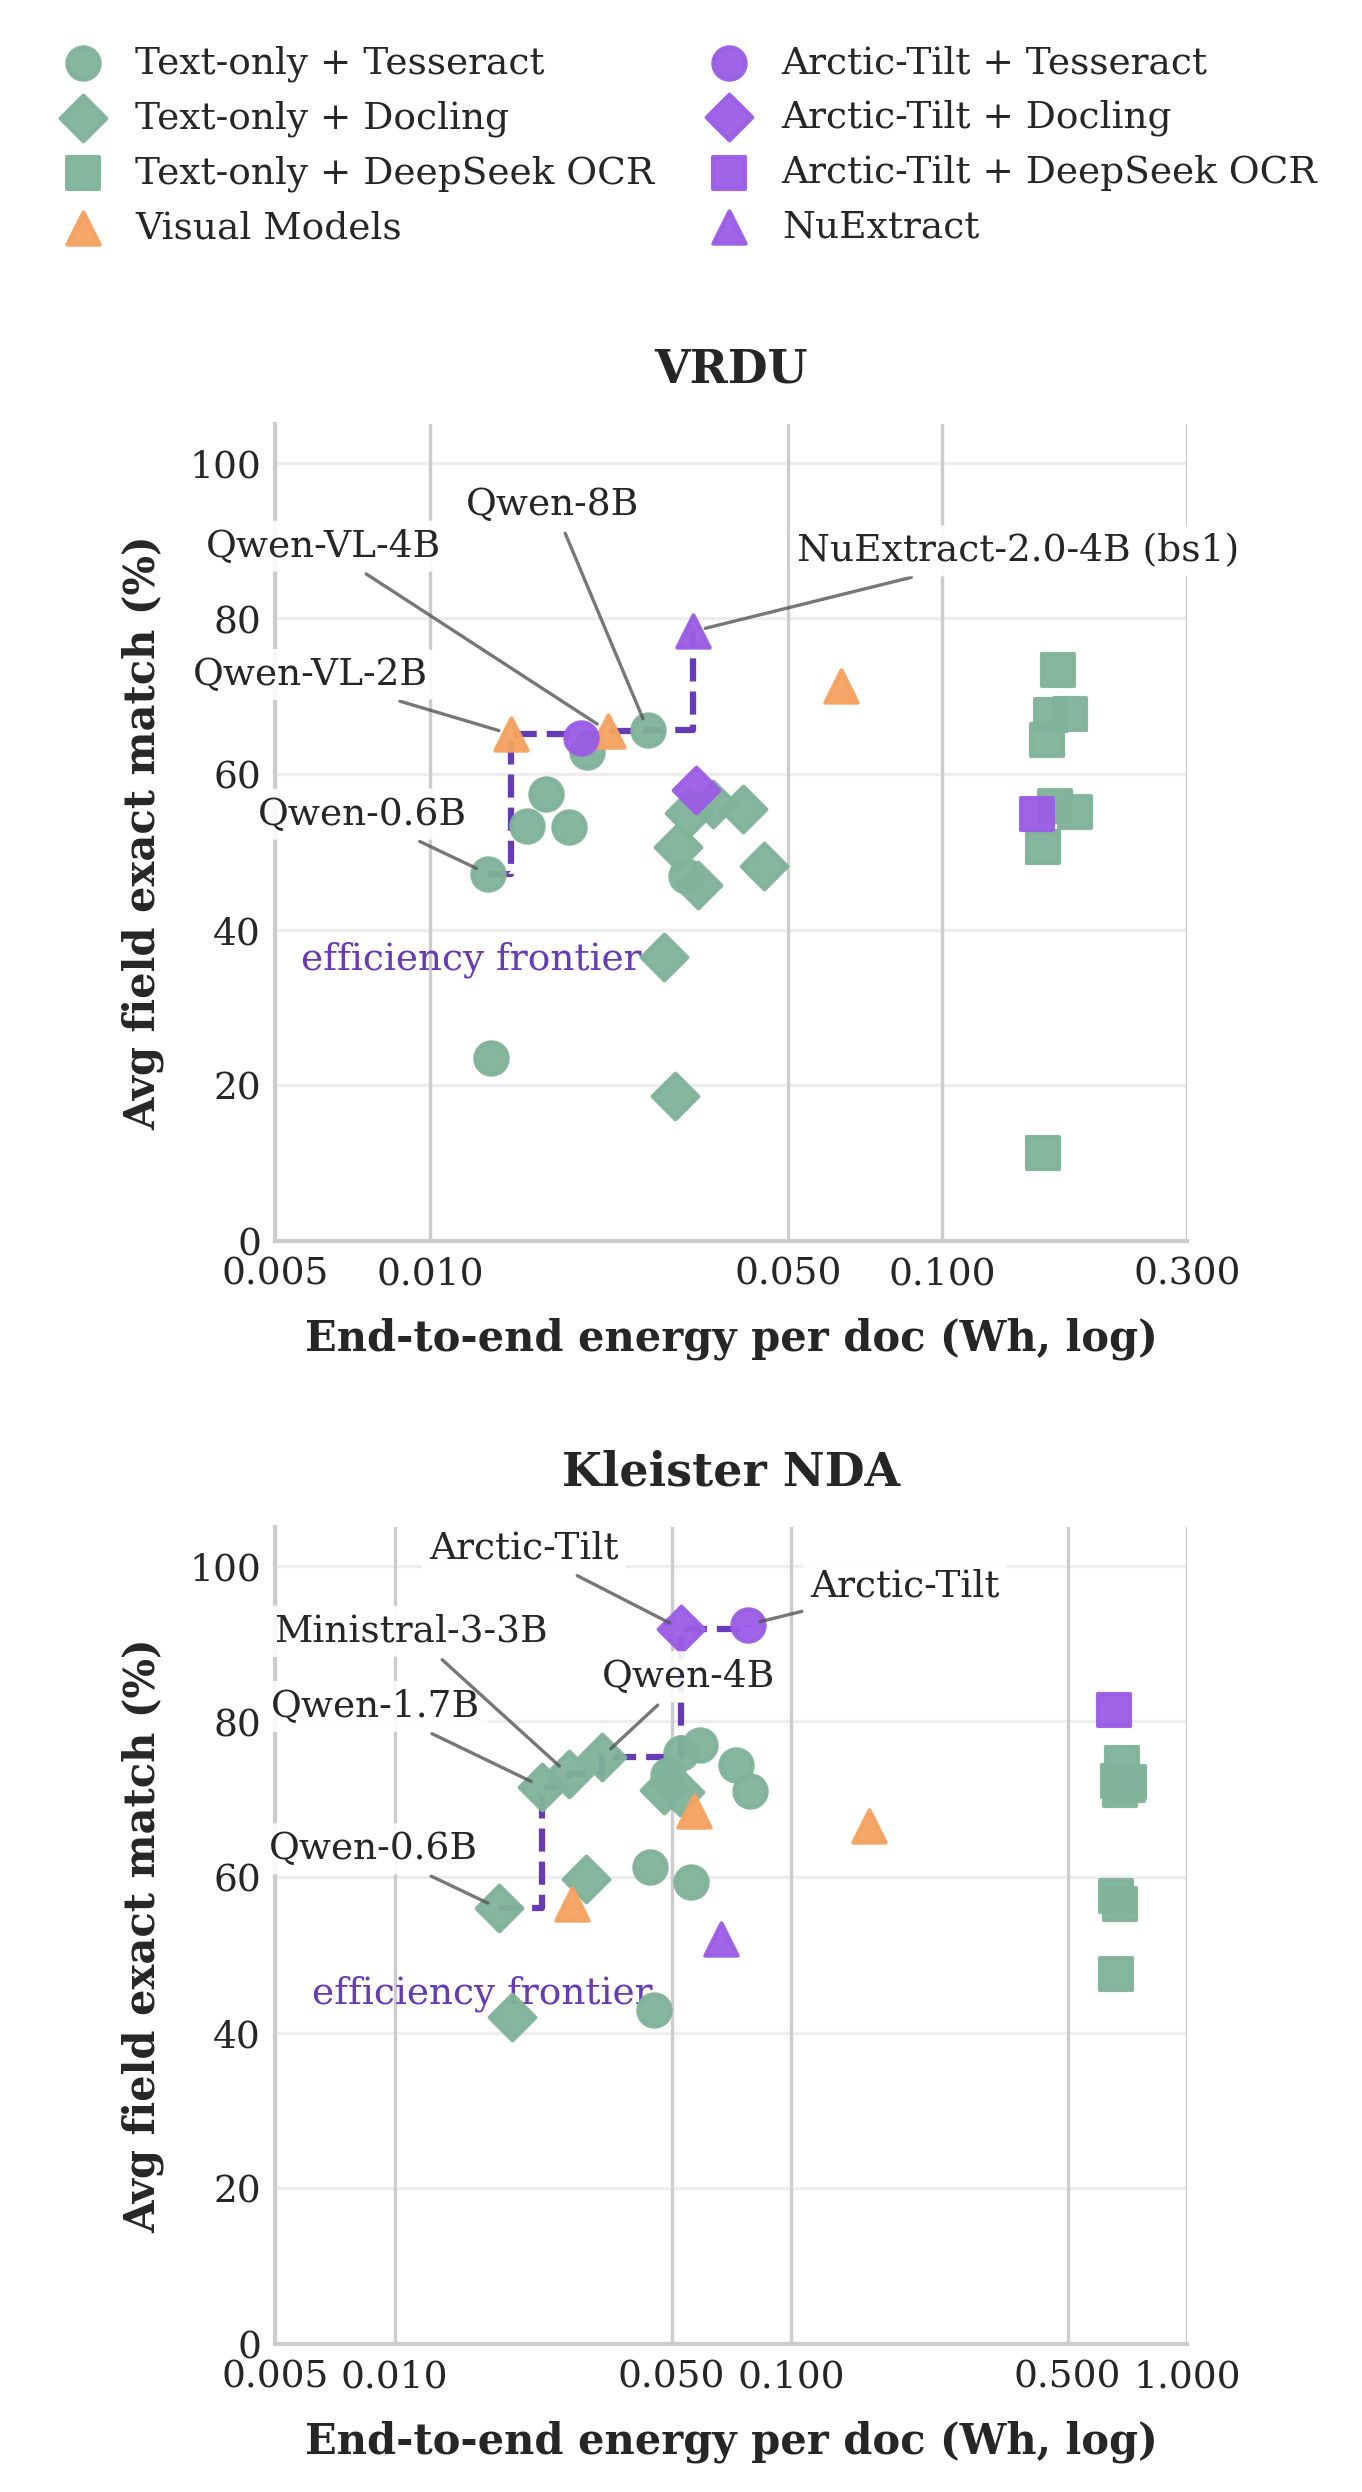

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 2. Reusable Helper Functions
def get_pareto_frontier(df, minimize_x=True, maximize_y=True):
    sorted_df = df.sort_values(
        by=['E2E_Energy_Doc', 'Exact_Match'],
        ascending=[minimize_x, not maximize_y]
    )
    frontier_rows = []
    best_y = -float('inf')
    for _, row in sorted_df.iterrows():
        if row['Exact_Match'] > best_y:
            frontier_rows.append(row)
            best_y = row['Exact_Match']
    return pd.DataFrame(frontier_rows)

def clean_model_name(model, batch_size):
    name = str(model)
    replacements = {'-Instruct': '', '-2512': '', '-v0.3': '', 'Qwen3-': '', 'Llama-3.2-': ''}
    for old, new in replacements.items():
        name = name.replace(old, new)
    if str(model).startswith('Qwen') and not name.startswith('Qwen'): name = 'Qwen-' + name
    elif str(model).startswith('Llama') and not name.startswith('Llama'): name = 'Llama-' + name
    if batch_size not in [10, 20]:
        name += f' (bs{int(batch_size)})'
    return name

def prep_dataset(df_all, target_dataset):
    df_plot = df_all[df_all['Dataset'] == target_dataset].copy()

    def is_unquantized(path):
        path_str = str(path).lower()
        if 'noquant' in path_str: return True
        if 'quant' in path_str and 'noquant' not in path_str: return False
        return True
    df_plot = df_plot[df_plot['File_Path'].apply(is_unquantized)].copy()

    if not df_plot.empty:
        df_plot['E2E_Energy_Doc'] = df_plot.apply(calc_end_to_end_energy, axis=1)
        df_plot['Category'] = df_plot.apply(categorize_model, axis=1)
        df_plot = df_plot[df_plot['Category'] != 'Other']

        target_bs = 10 if target_dataset == 'VRDU' else 20
        df_plot['is_target_bs'] = df_plot['Batch_Size'] == target_bs
        df_plot = df_plot.sort_values(
            by=['Model', 'Category', 'is_target_bs', 'Batch_Size', 'Exact_Match'],
            ascending=[True, True, False, False, False]
        )
        df_plot = df_plot.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)
    return df_plot

# 3. Expanded Offsets to Prevent Overlap
custom_offsets = {
    # VRDU Offsets
    'Qwen-0.6B': (-5, 10),
    'Qwen-VL-2B': (-20, 10),
    'Qwen-8B': (-2, 50),
    'NuExtract-2.0-4B (bs1)': (25, 15),

    # Specific offset for the blue Tesseract point
    ('Arctic-Tilt', 'Arctic-Tilt + Tesseract'): (15, 5),

    # Kleister NDA Offsets
    'Qwen-0.6B (bs20)': (-35, 15),
    'Ministral-3-3B': (-5, 30),
    'Qwen-4B': (0, 15),
    'Arctic-Tilt (bs10)': (25, 10),
    'Arctic-Tilt (bs20)': (25, 10),
    'Qwen-VL-4B': (-40, 40)
}

# 4. Adjusted Figure Size for a Single Column Layout (Stacked 2x1)
fig, axes = plt.subplots(2, 1, figsize=(4, 8))
datasets = ['VRDU', 'Kleister NDA']

# 5. Plotting Loop
for i, dataset in enumerate(datasets):
    ax = axes[i]
    df_plot = prep_dataset(df_all, dataset)

    if df_plot.empty:
        continue

    frontier_df = get_pareto_frontier(df_plot)

    # Scatter points
    for category, style in category_styles.items():
        subset = df_plot[df_plot['Category'] == category]
        if not subset.empty:
            ax.scatter(
                subset['E2E_Energy_Doc'], subset['Exact_Match'],
                color=style['color'], marker=style['marker'], s=60,
                label=category, zorder=4, alpha=0.95
            )

    # Draw frontier
    if not frontier_df.empty:
        ax.step(
            frontier_df['E2E_Energy_Doc'], frontier_df['Exact_Match'],
            where='post', color='#673AB7', linestyle='--', linewidth=1.5, zorder=2
        )
        first_row = frontier_df.iloc[0]
        ax.annotate(
            'efficiency frontier',
            xy=(first_row['E2E_Energy_Doc'], first_row['Exact_Match']),
            xytext=(-4, -16), textcoords='offset points', color='#673AB7',
            fontsize=9, ha='center', va='top'
        )

    # Add labels
    frontier_sorted = frontier_df.sort_values(by='E2E_Energy_Doc').reset_index(drop=True)
    labeled_models = set()

    for _, row in frontier_sorted.iterrows():
        x, y = row['E2E_Energy_Doc'], row['Exact_Match']
        label = clean_model_name(row['Model'], row['Batch_Size'])

        unique_id = (label, row['Category'])

        if unique_id in labeled_models: continue
        labeled_models.add(unique_id)

        if unique_id in custom_offsets:
            dx, dy = custom_offsets[unique_id]
        else:
            dx, dy = custom_offsets.get(label, (-15, 15))

        ax.annotate(
            label, xy=(x, y), xycoords='data', xytext=(dx, dy), textcoords='offset points',
            ha='right' if dx < 0 else 'left', va='bottom',
            fontsize=9,
            zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9),
            arrowprops=dict(arrowstyle='-', color='#555555', lw=0.8, alpha=0.8, shrinkA=1, shrinkB=3)
        )

    # Axis Formatting
    ax.set_title(dataset, fontsize=11, fontweight='bold', pad=10)
    ax.set_xscale('log')
    ax.set_xlabel('End-to-end energy per doc (Wh, log)', fontsize=10, labelpad=6)
    ax.tick_params(axis='both', labelsize=9)

    ax.set_ylabel('Avg field exact match (%)', fontsize=10, labelpad=6)

    if i == 0:
        ax.set_xlim(left=0.005, right=0.3)
        ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.3])
    else:
        ax.set_xlim(left=0.005, right=1.0)
        ax.set_xticks([0.005, 0.01, 0.05, 0.1, 0.5, 1.0])

    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='-', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 6. Shared Legend (Adjusted positioning)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = fig.legend(
    by_label.values(), by_label.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.96), # Decreased from 1.0 to pull the legend down
    ncol=2,
    frameon=False,
    fontsize=9,
    handletextpad=0.4, columnspacing=1.0
)

# 7. Final Adjustments and Save
fig.tight_layout()
# Increased 'top' from 0.85 to 0.90 to push the plots closer to the legend
fig.subplots_adjust(top=0.90, bottom=0.1, hspace=0.35)

plt.savefig(
    'pareto_e2e_stacked.pdf',
    format='pdf',
    bbox_inches='tight',
    bbox_extra_artists=(lgd,)
)
plt.show()